# Parameter Sensitivity and Emulator Analysis

In [61]:
import os
import numpy as np
import xarray as xr
import pandas as pd

import fates_calibration_library.utils as utils
import fates_calibration_library.clm_functions as clm
import fates_calibration_library.emulator_functions as em
import fates_calibration_library.surface_data_functions as surface
from fates_calibration_library.TFClass import TFEmulator

import tensorflow as tf
from esem.utils import get_random_params

import matplotlib.pyplot as plt
import importlib

## Set Up
Load files, set up ensemble information

In [62]:
# dataset with land area 
land_frac_ds_file = os.path.join("/glade/derecho/scratch/afoster/archive",
                            "ctsm60SP_bigleaf_fullgrid/lnd/hist",
                            "ctsm60SP_bigleaf_fullgrid.clm2.h0.0001-02-01-00000.nc")

surdat_dir = "/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/surfdata_esmf/ctsm5.4.0/"
surdat_2deg = os.path.join(surdat_dir, "surfdata_1.9x2.5_hist_2000_16pfts_c250617.nc")

obs_config_file = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/ilamb_conversion.yaml'
obs_config = utils.get_config_file(obs_config_file)

pft_id_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/fates_pft_ids.yaml'
pft_ids = utils.get_config_file(pft_id_config)

# directories
mesh_dir = '/glade/work/afoster/FATES_calibration/mesh_files'
hist_dir = '/glade/work/afoster/FATES_calibration/history_files/compiled_files'
emulator_dir = '/glade/work/afoster/FATES_calibration/emulators'
fig_dir = '/glade/work/afoster/FATES_calibration/figures'
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'

# grab pft names
default_param = xr.open_dataset(os.path.join(param_dir,
                                             'fates_params_default_sci.1.85.1_api.40.0.0_crops.nc'))
all_pfts = [str(pft).replace("b'", "").replace("'", "").strip() for pft in default_param.fates_pftname.values]
default_norm = pd.read_csv(os.path.join(param_dir, 'normalized_parameters.csv'), index_col=[0])

# variables to emulate
calibration_vars = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF']

# number of samples to choose
n_sample = 10000

In [63]:
# information about each ensemble
ens_dict = {'dompft':
            {'mesh_file': os.path.join(mesh_dir, 'dominant_grid_mesh.nc'),
             'land_mask_file': os.path.join(mesh_dir, 'dominant_grid.nc'),
             'ensemble_file': os.path.join(hist_dir, 'fates_dompft_annual_means.nc'),
             'lhc_key_file': os.path.join(param_dir, 'fates_lh', 'fates_lh_key.csv'),
             'pfts': [1, 2, 3, 12, 13, 14],
             'obs_df': os.path.join(mesh_dir, 'dominant_grid.csv'),
            },
            'codompft':
            {'mesh_file': os.path.join(mesh_dir, 'co-dominant_grid_mesh.nc'),
             'land_mask_file': os.path.join(mesh_dir, 'co-dominant_grid.nc'),
             'ensemble_file': os.path.join(hist_dir, 'fates_codompft_annual_means.nc'),
             'lhc_key_file': os.path.join(param_dir, 'fates_lh_codom', 'fates_lh_key.csv'),
             'pfts': [4, 6, 11, 14],
             'obs_df': os.path.join(mesh_dir, 'co-dominant_grid.csv'),
            }
           }

In [64]:
# choose ensemble
ensemble = 'codompft'

### Load Latin Hypercube Key

In [65]:
lhc_key = pd.read_csv(ens_dict[ensemble]['lhc_key_file'], index_col=[0])
lhc_key = lhc_key.drop(columns=['ensemble'])
param_names = lhc_key.columns
num_params = len(param_names)

### Load Observations

In [66]:
obs = pd.read_csv(ens_dict[ensemble]['obs_df'], index_col=[0])

## Evaluate Emulators
Loop through each pft and variable to investigate ensemble and emulator spread

2026-01-06 11:42:37.940852: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/glade/work/afoster/conda-envs/fates_calibration/lib/python3.11/site-packages/SALib/sample/saltelli.py:109: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (4000) is equal to `2^n`.
        
  warnings.warn(msg)
/glade/work/afoster/conda-envs/fates_calibration/lib/python3.11/site-packages/SALib/sample/saltelli.py:109: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (4000) is equal to `2^n`.
        
  warnings.warn(msg)
/glade/work/afoster/conda-envs/fates_calibration/lib/python3.11/site-packages/SALib/sample/saltelli.py:109: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (4000) is equal to `2^n`.
        
  warnings.warn(msg)
/glade/work/afoster/conda-envs/fates_calib

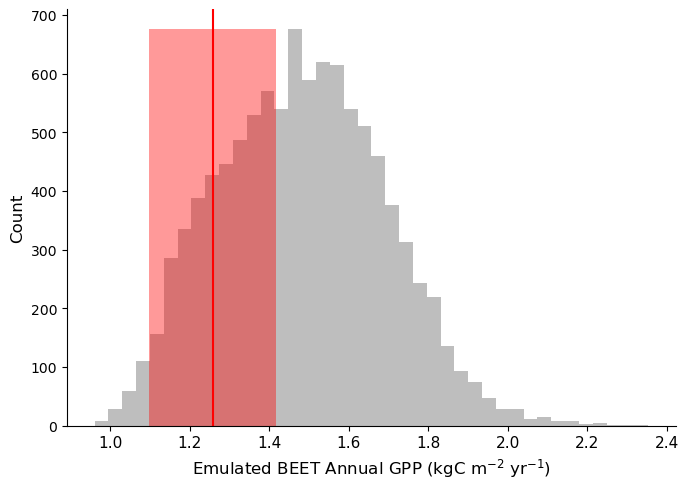

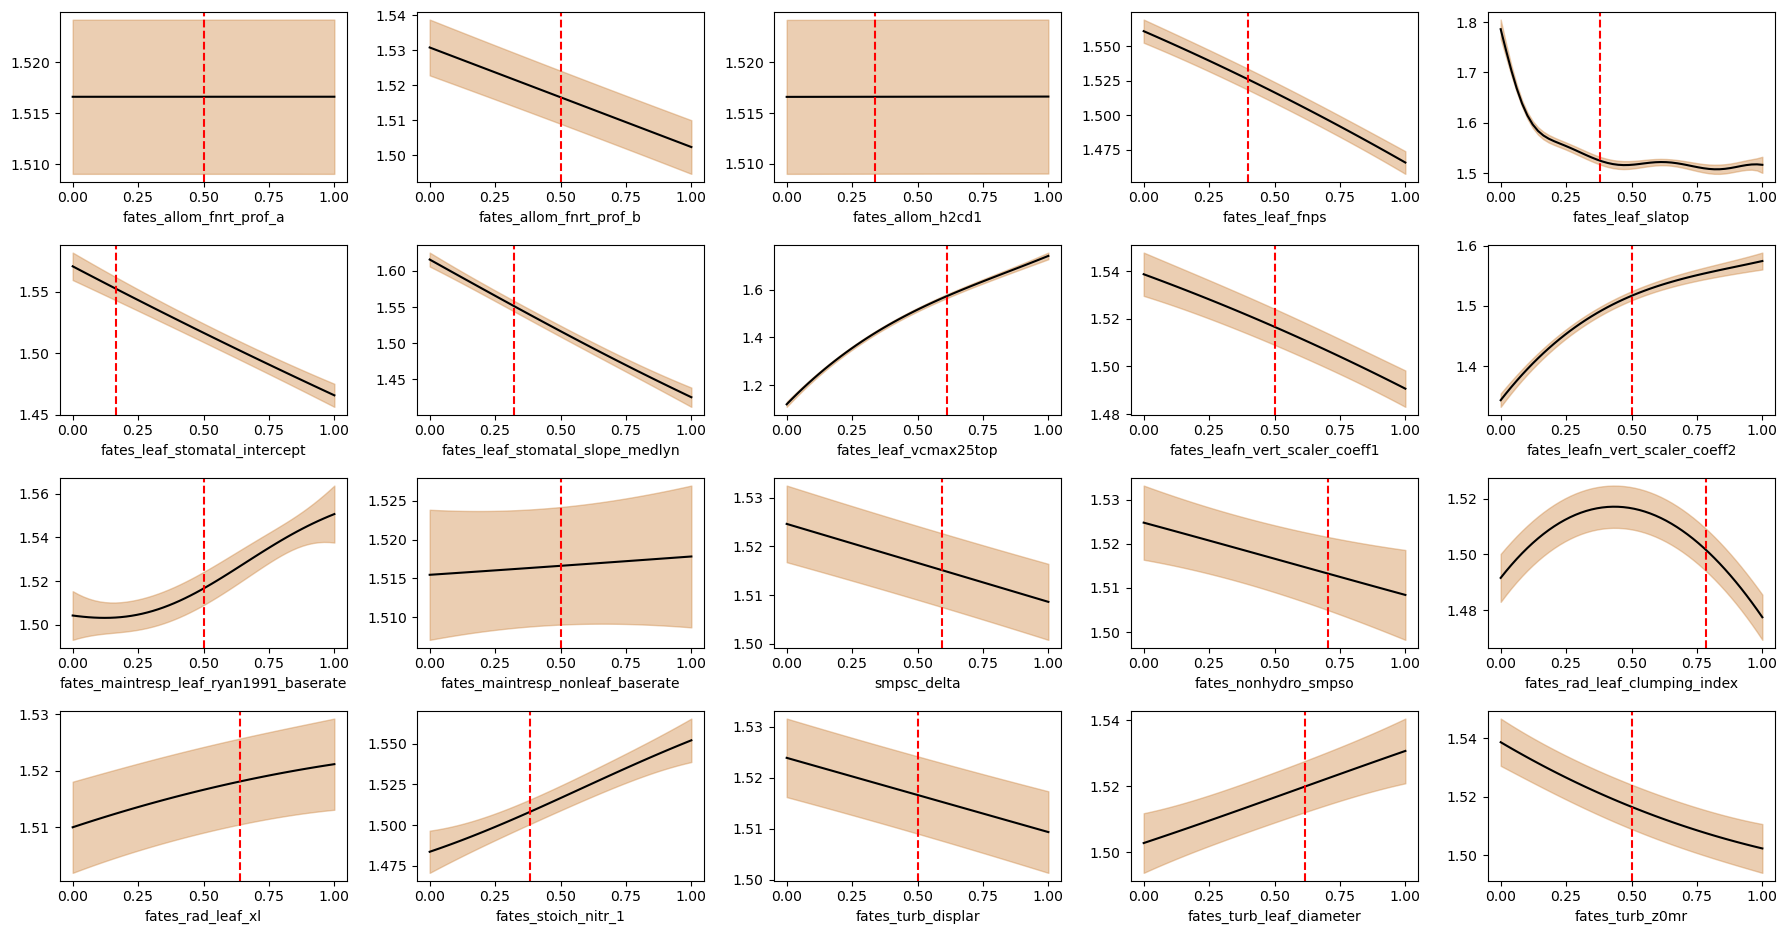

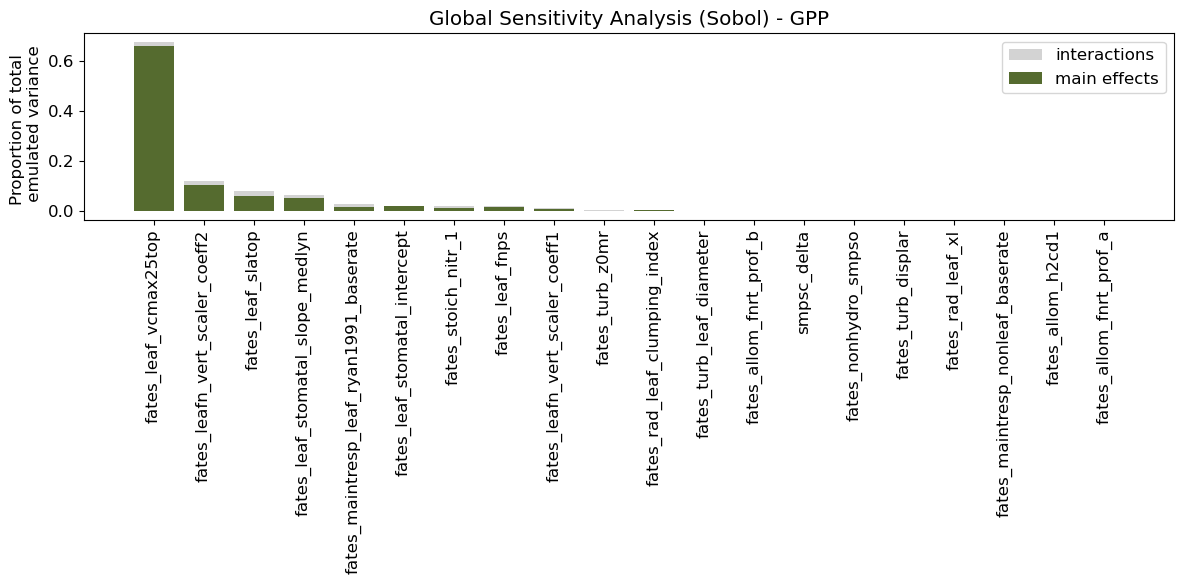

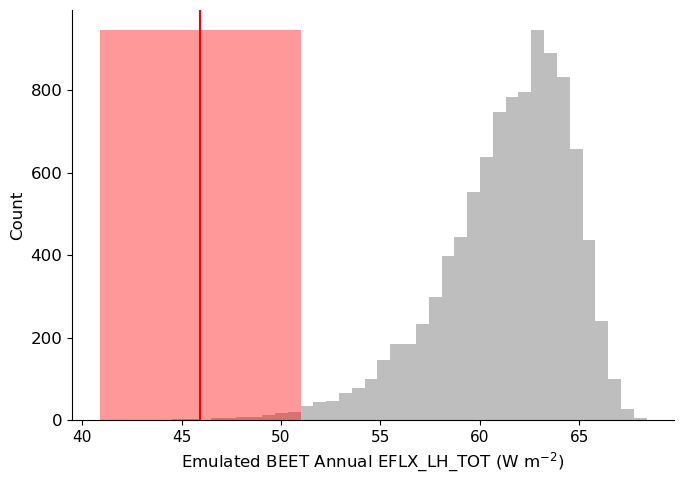

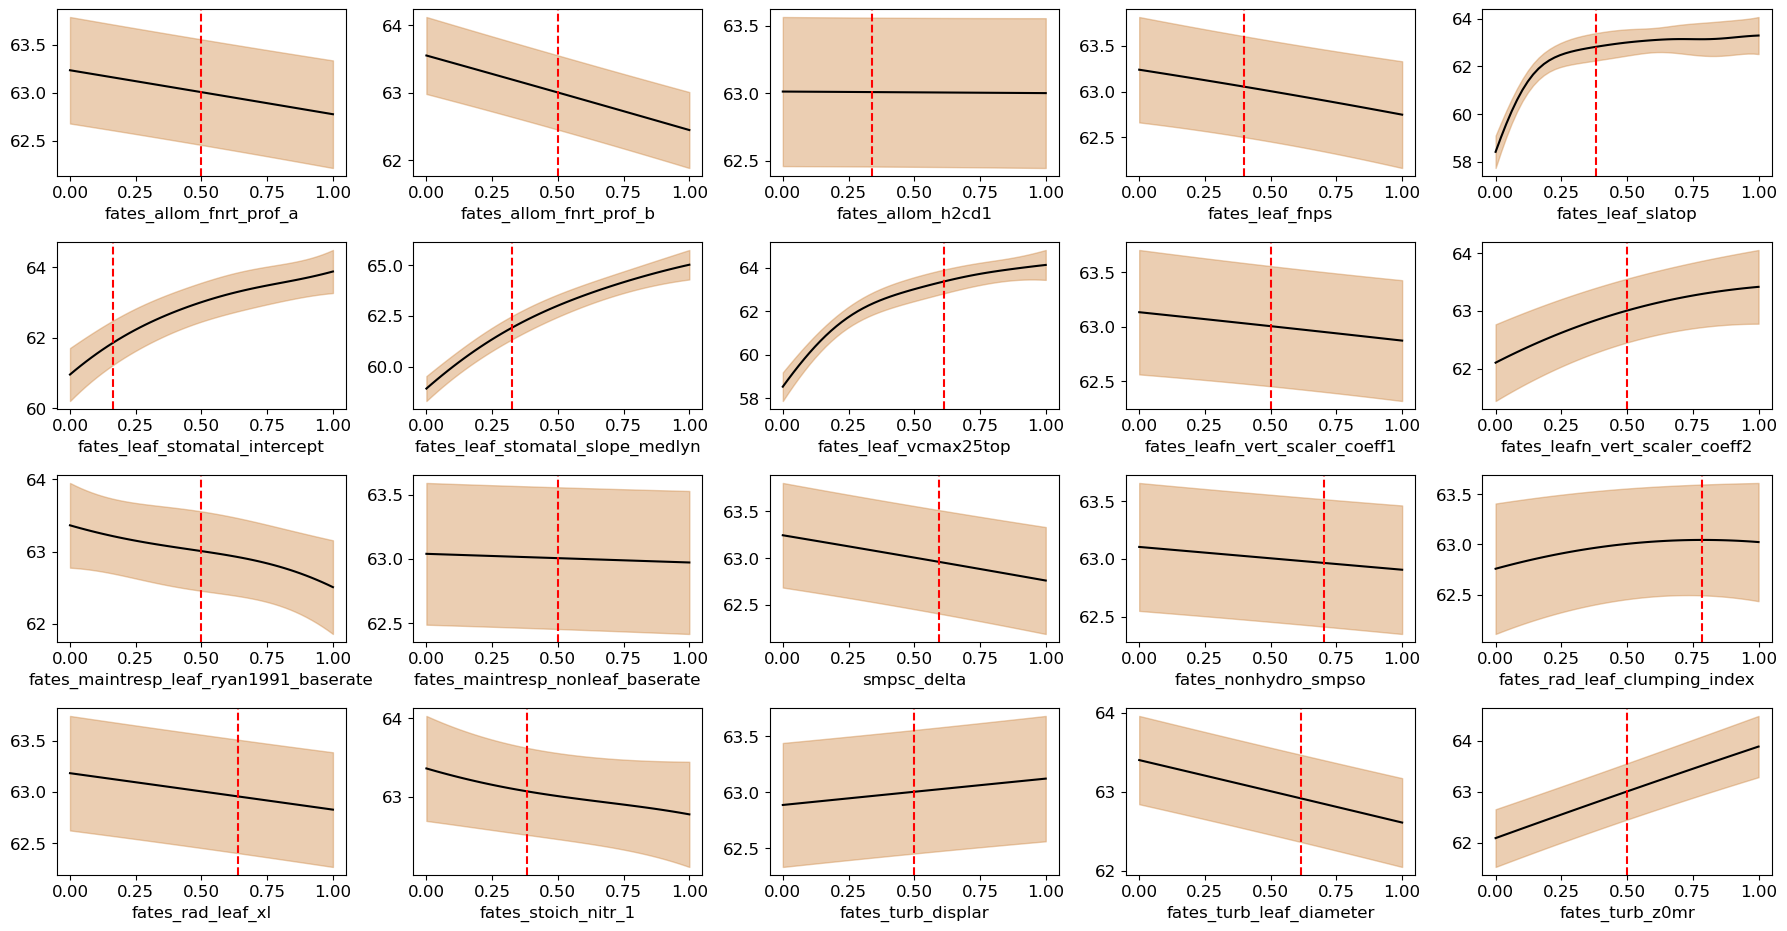

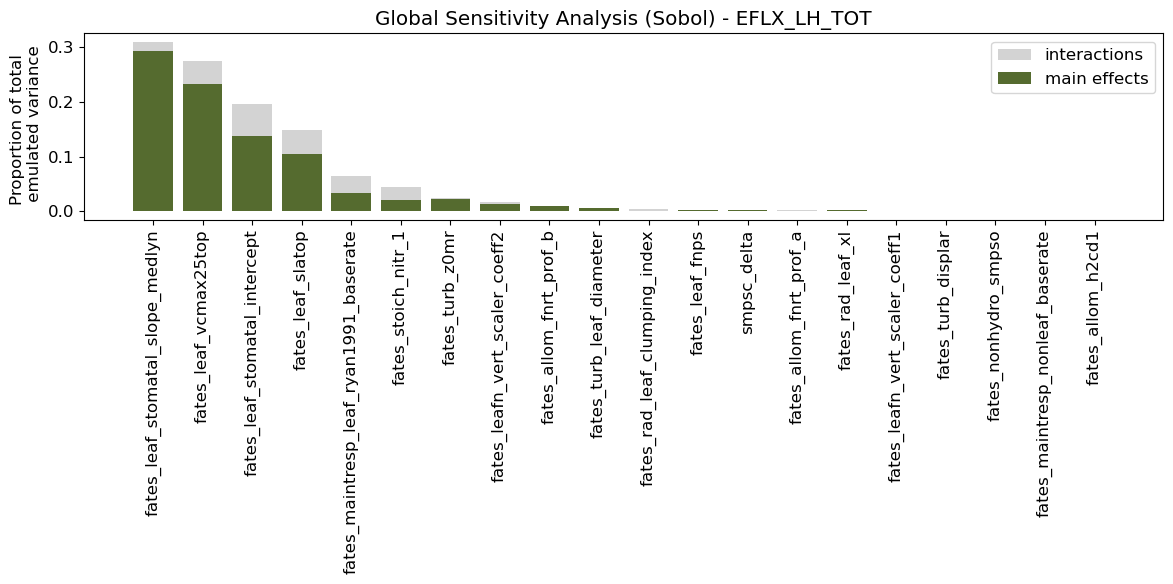

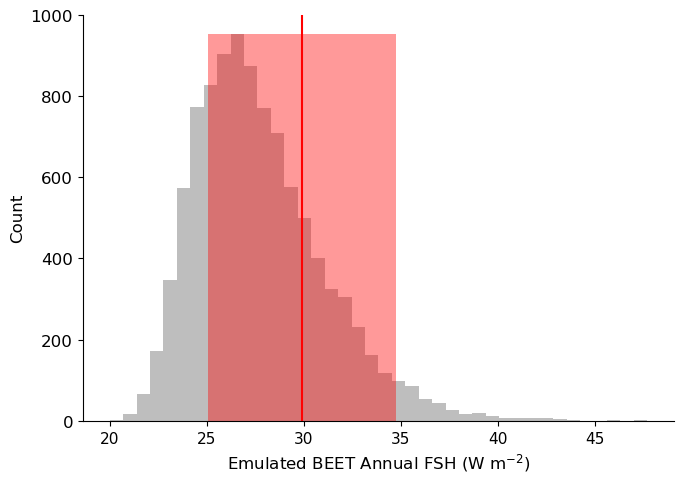

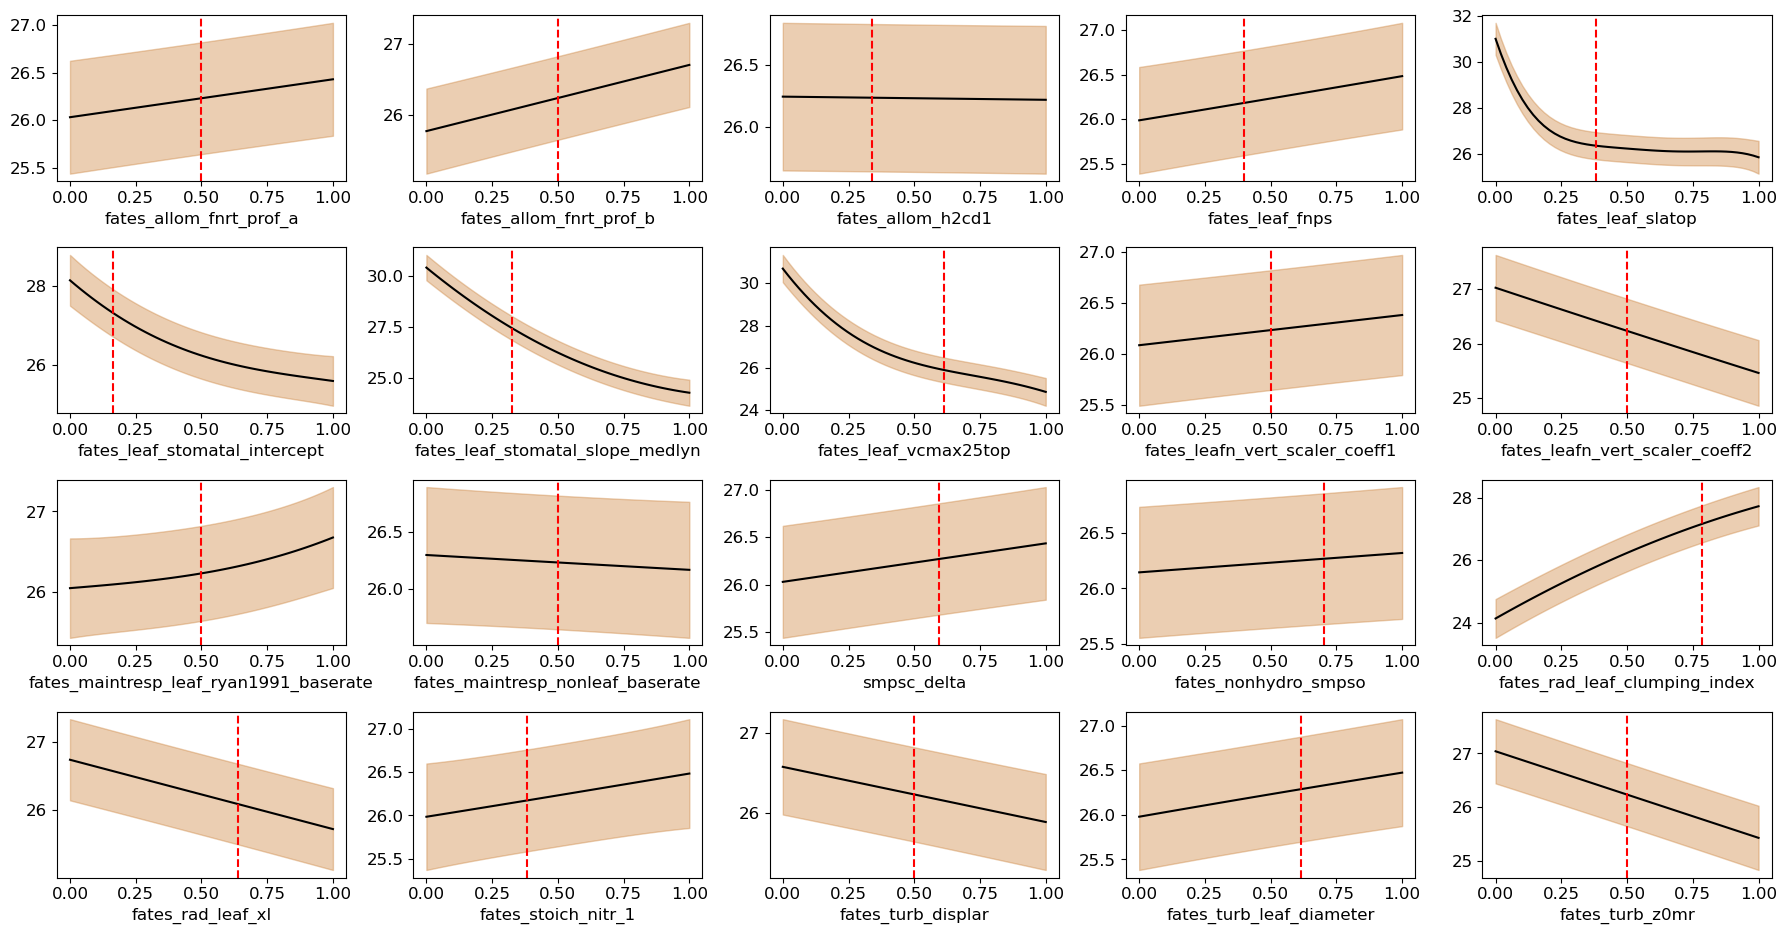

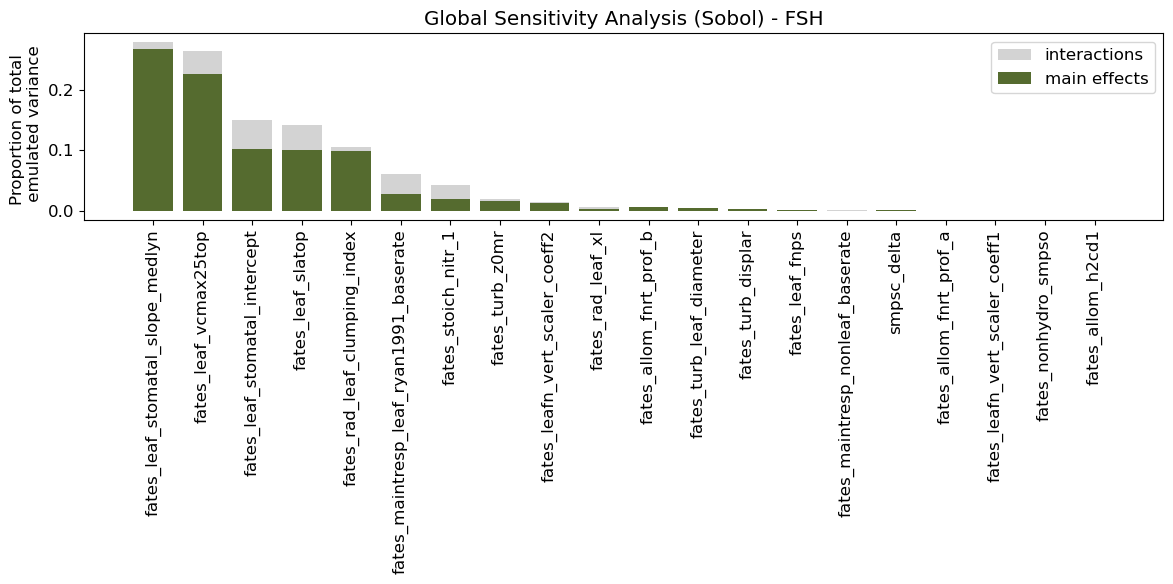

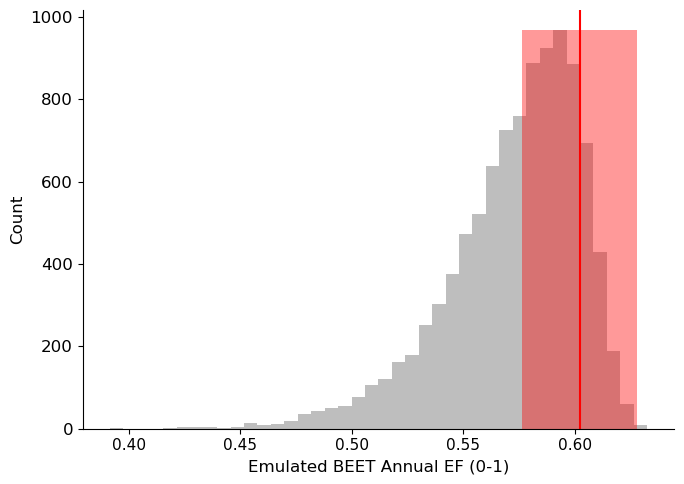

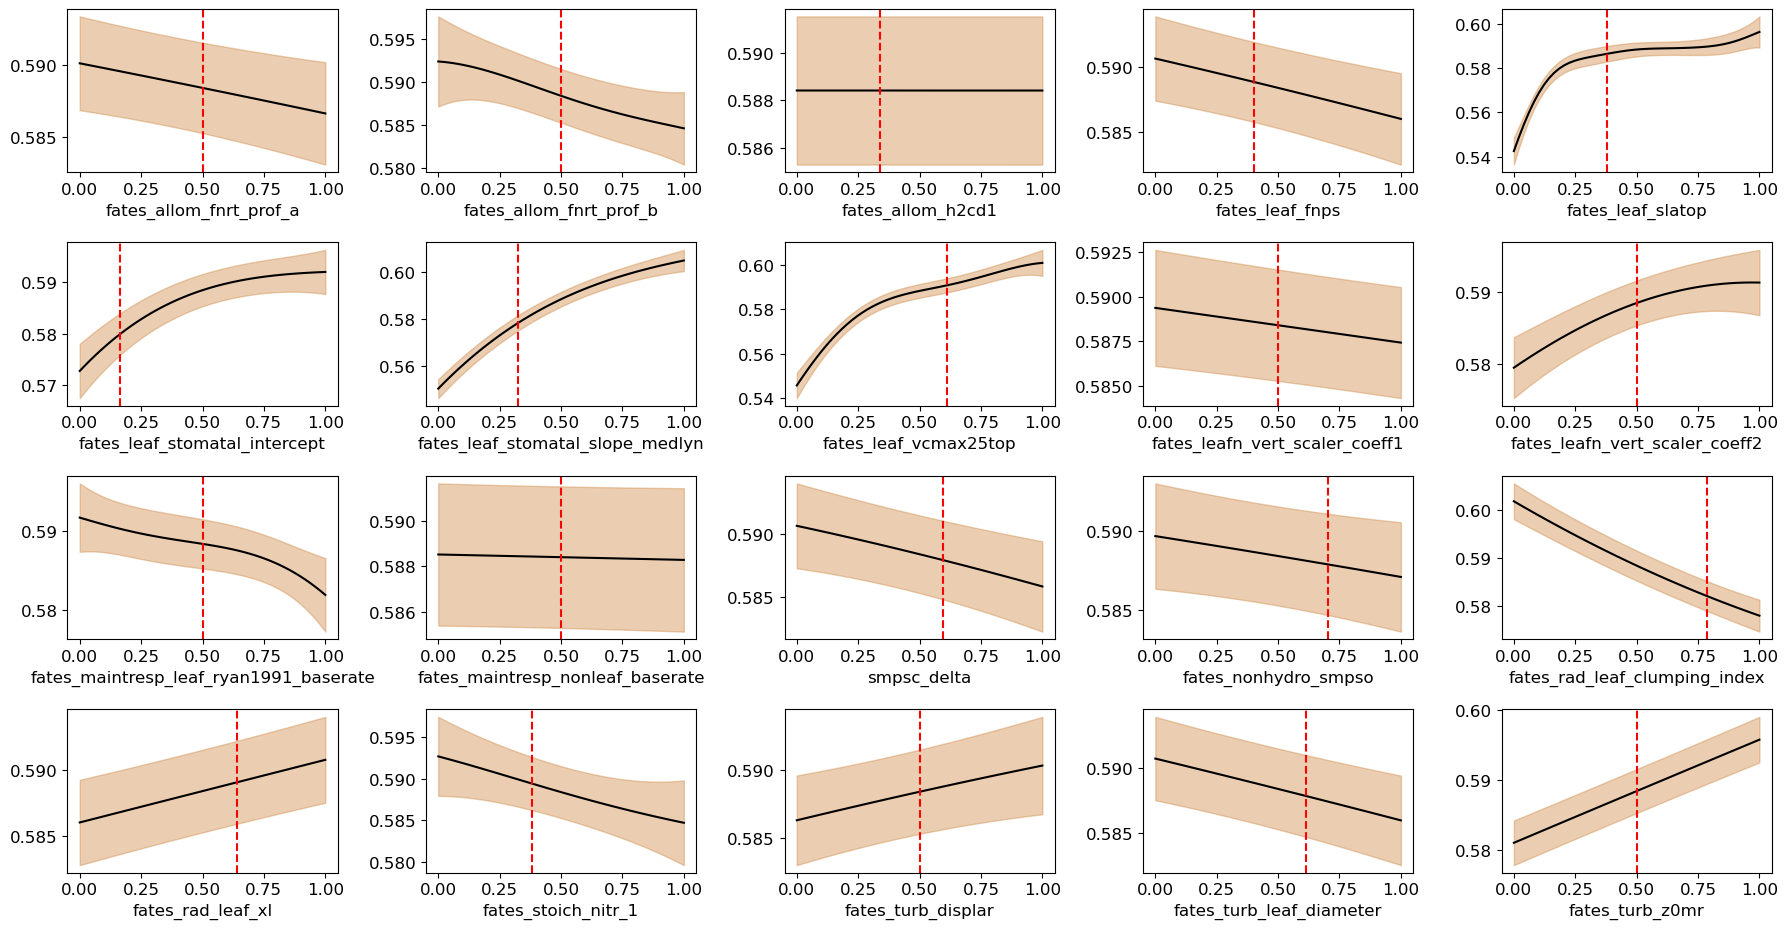

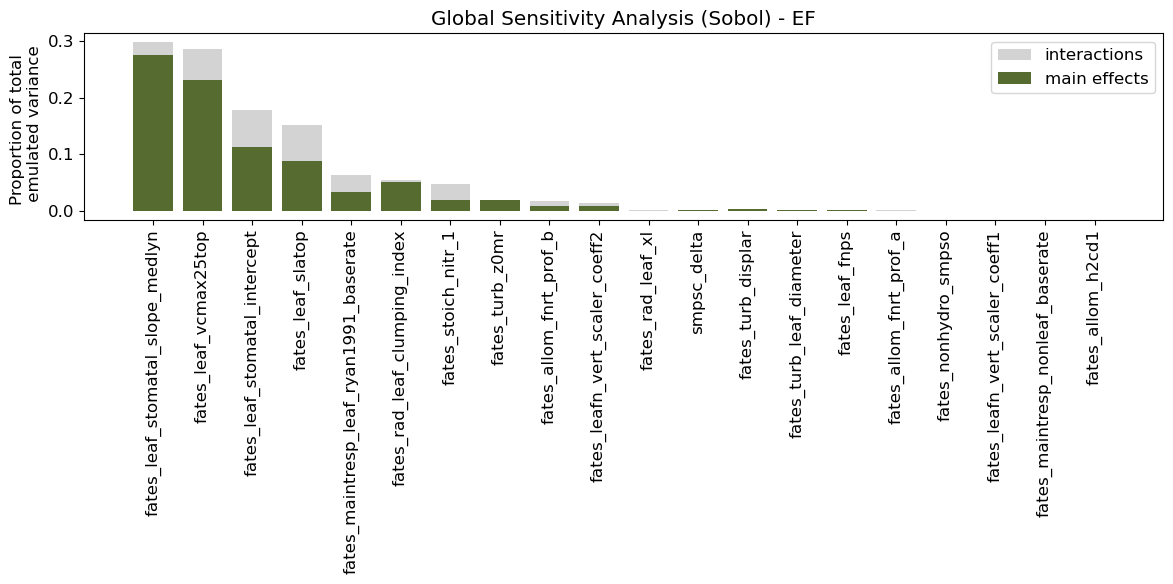

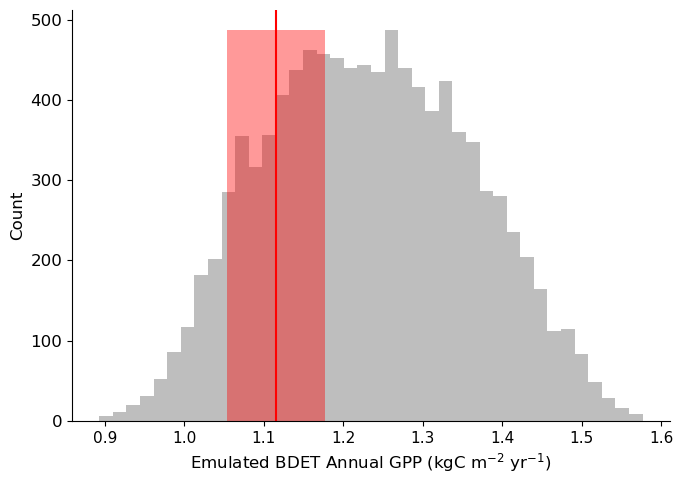

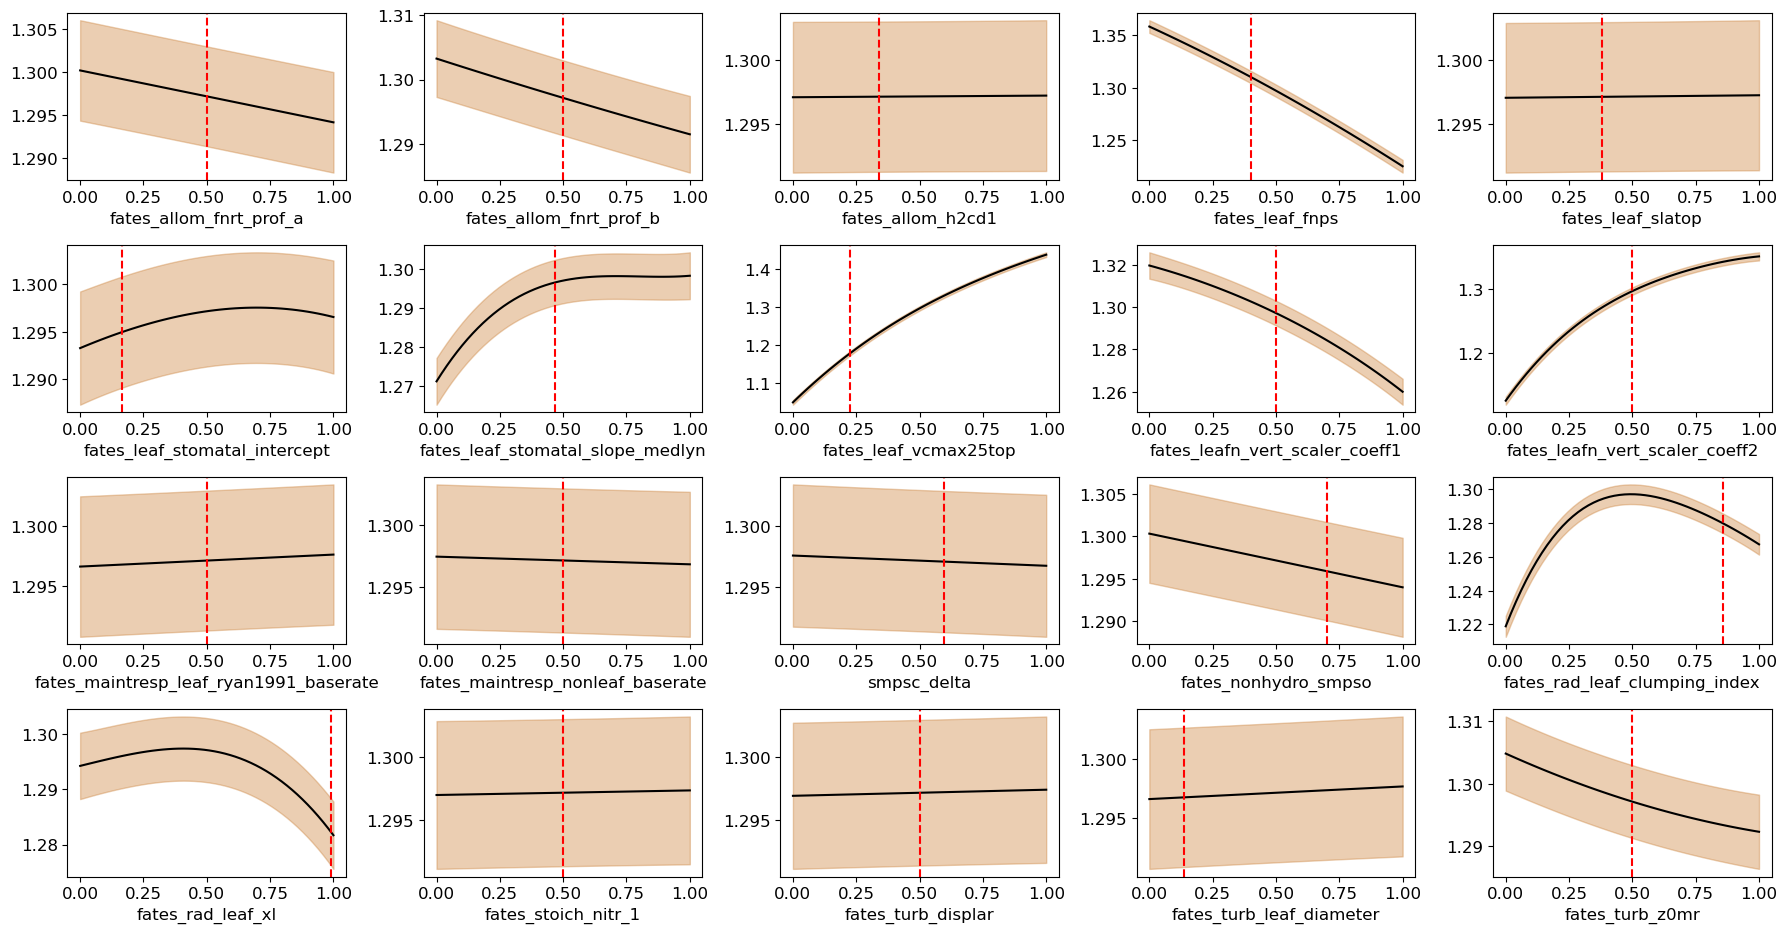

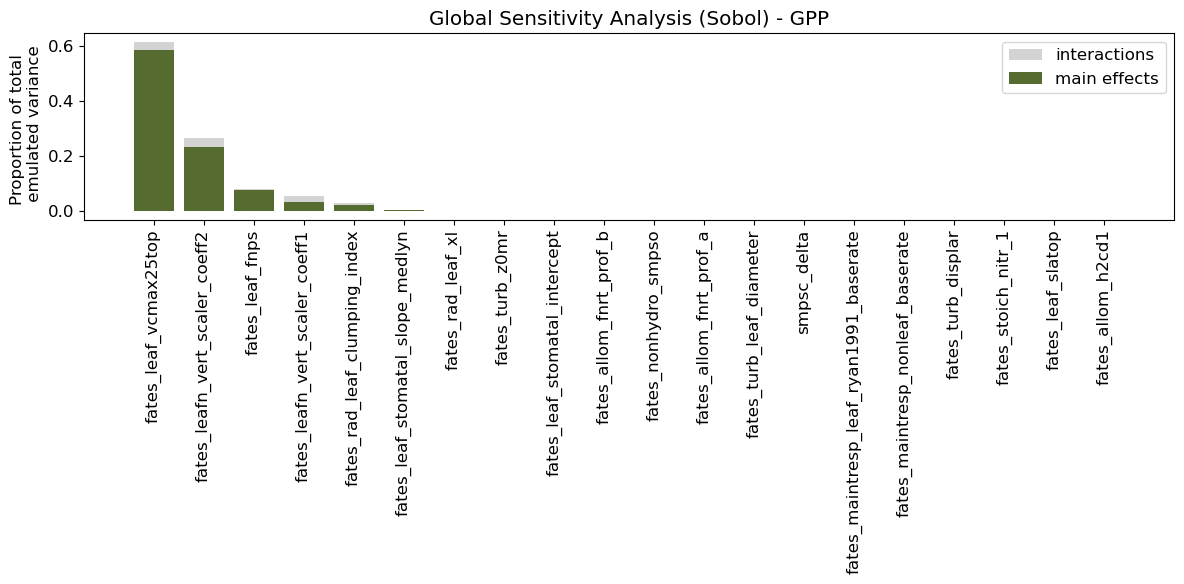

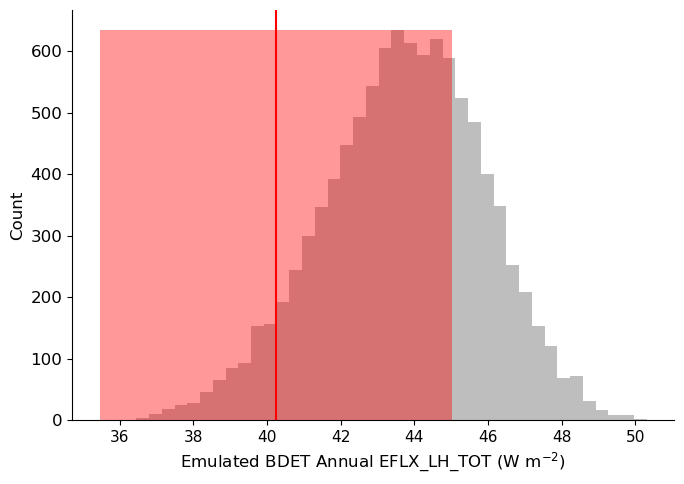

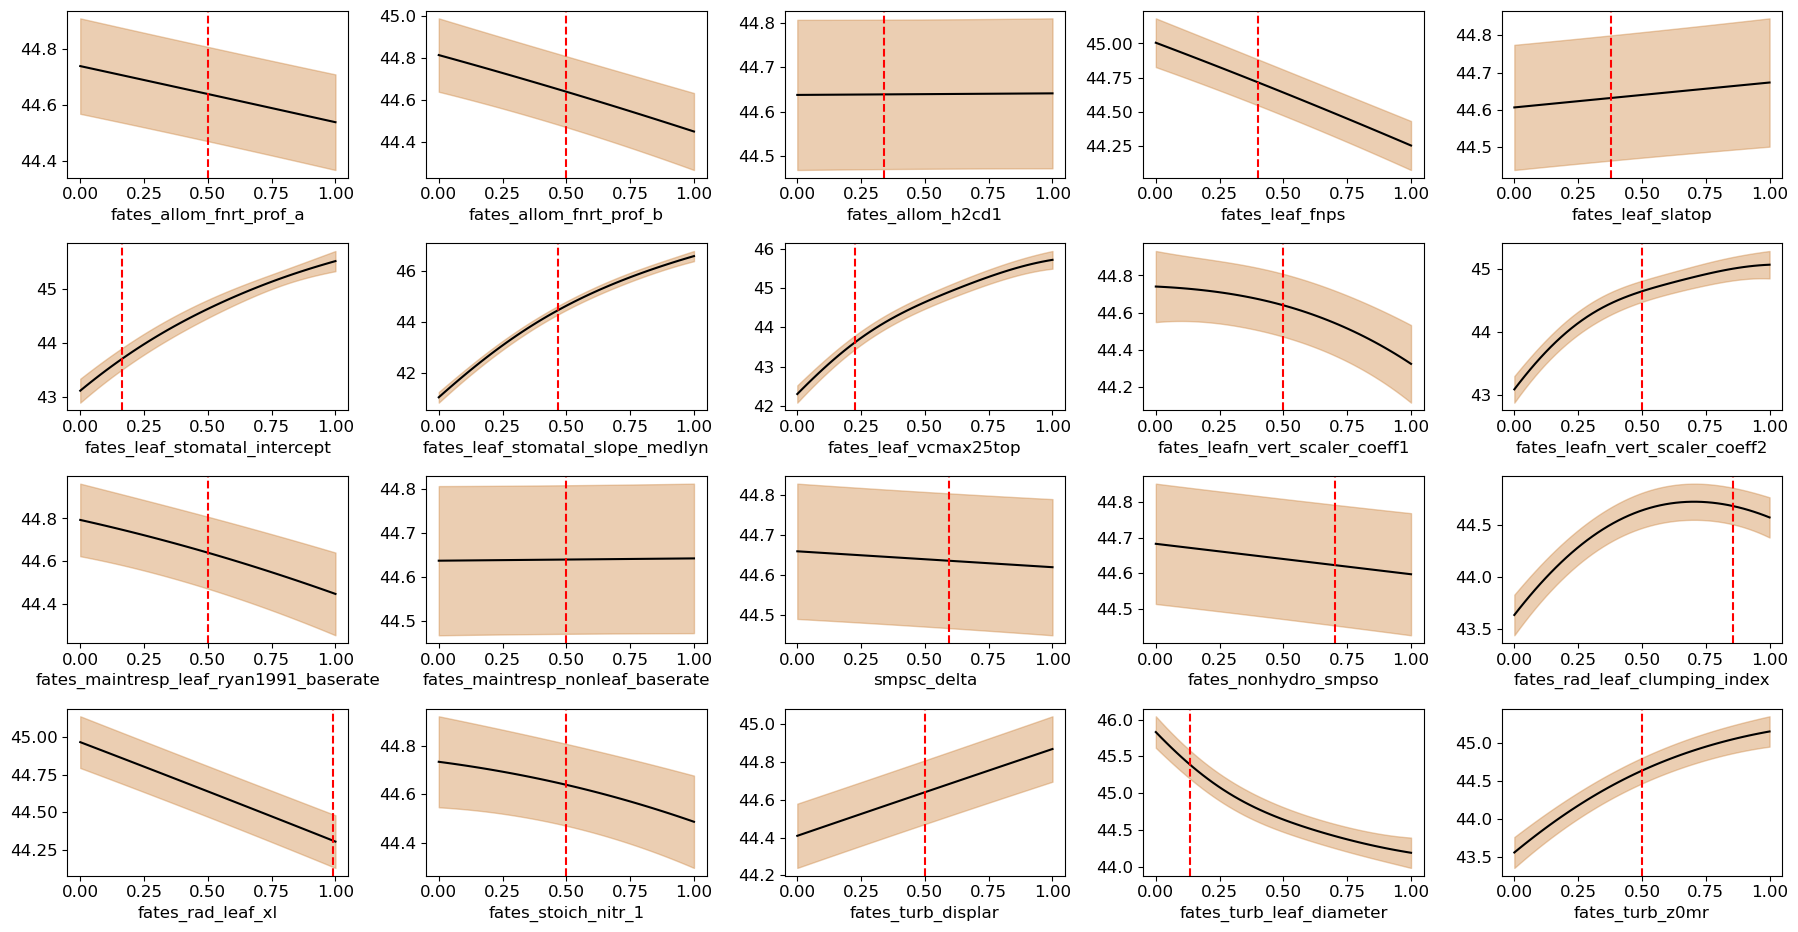

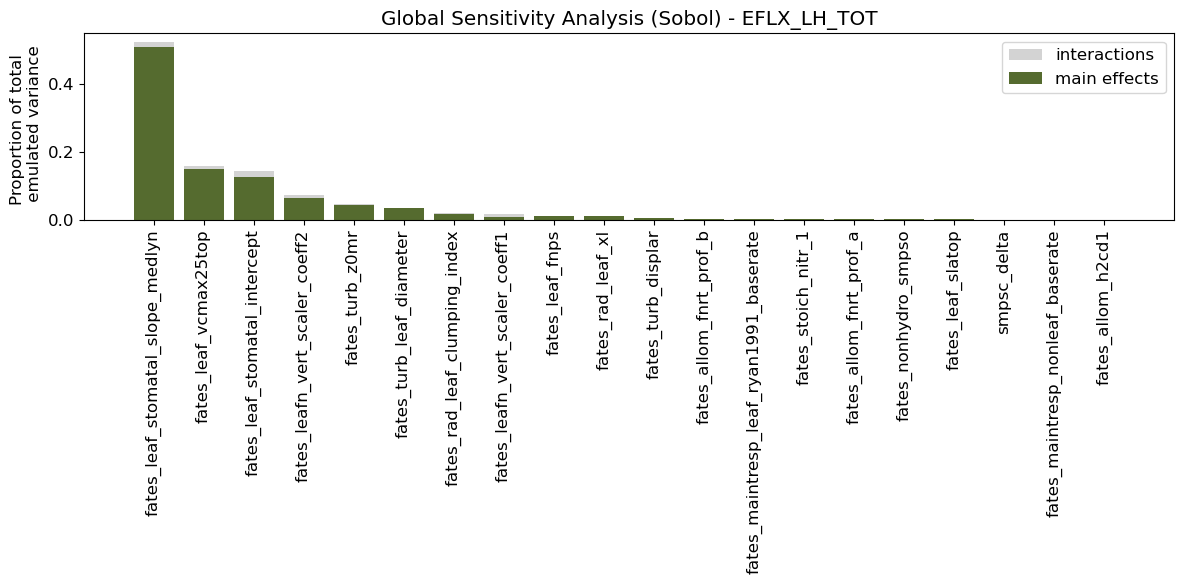

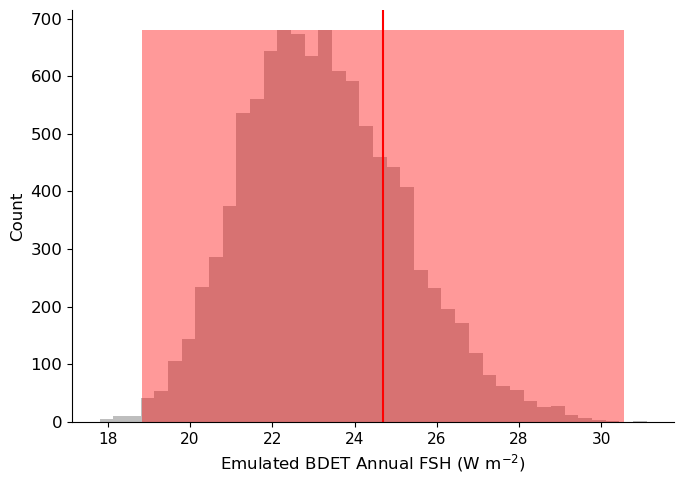

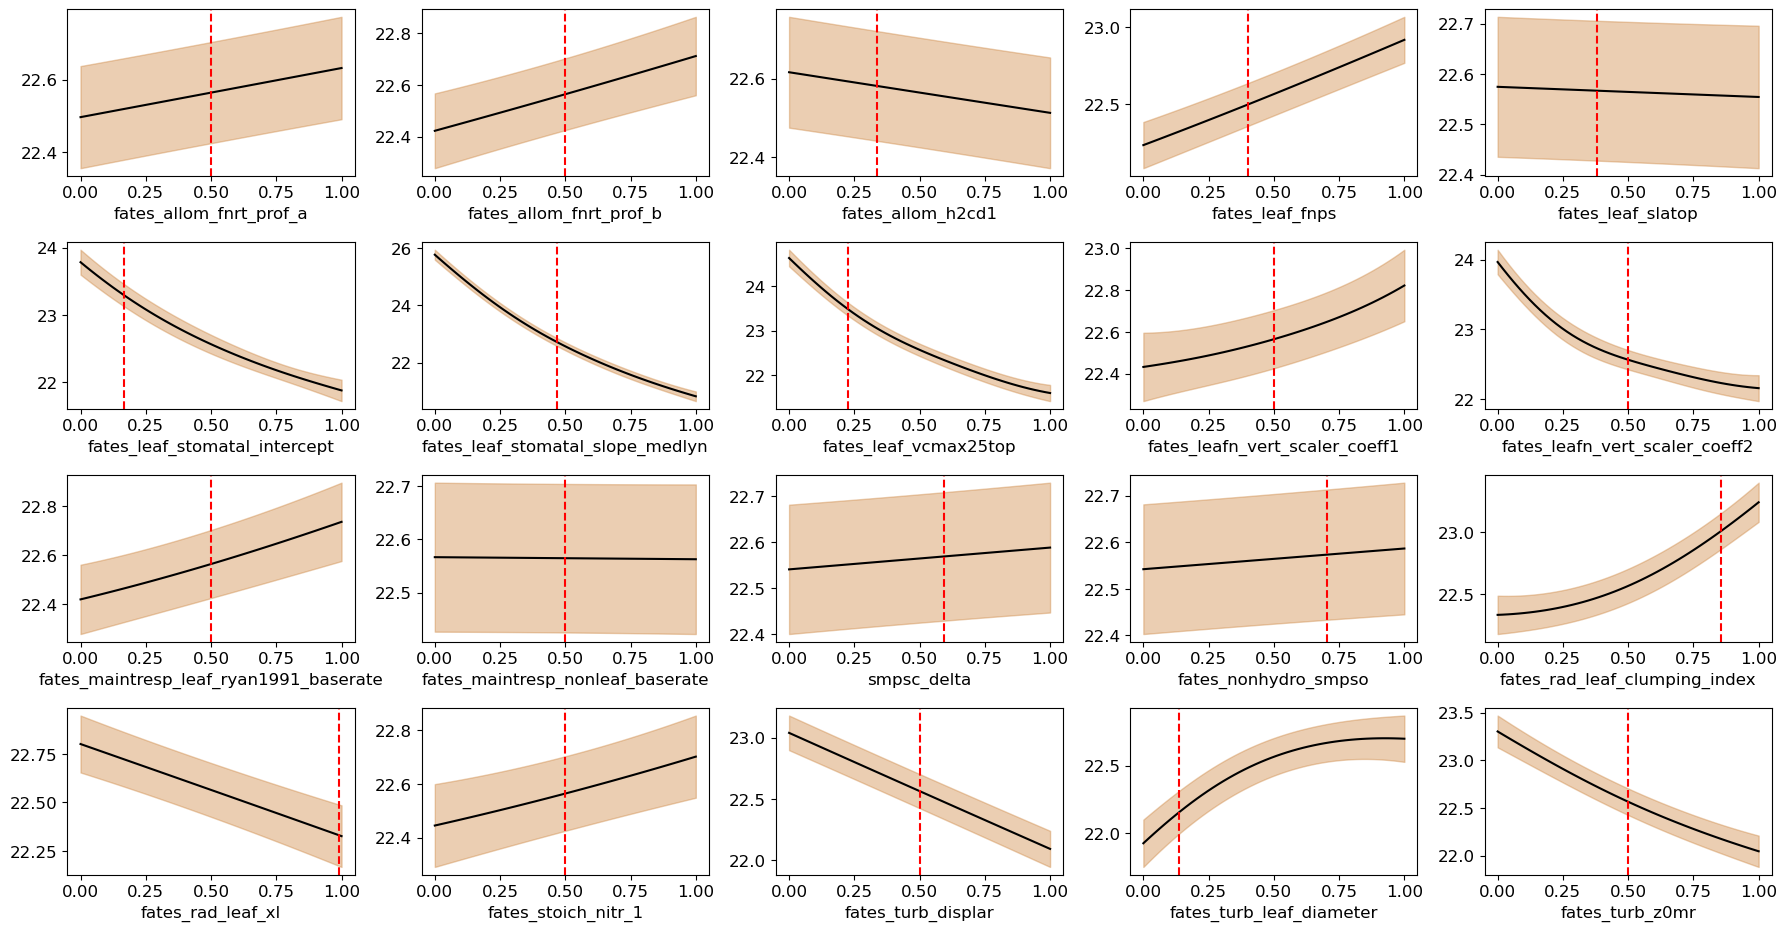

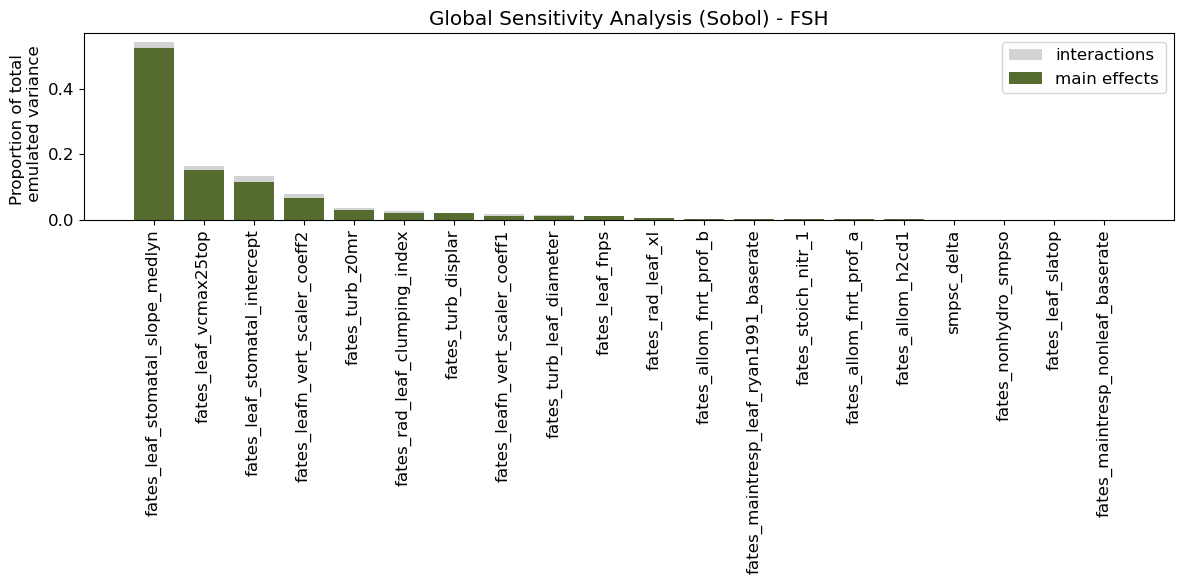

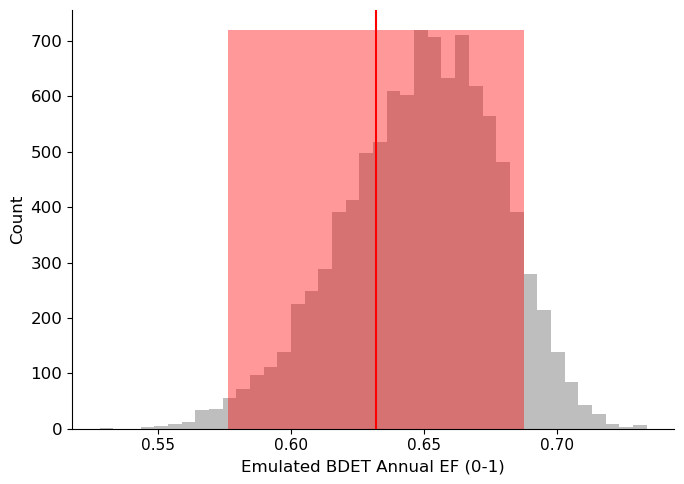

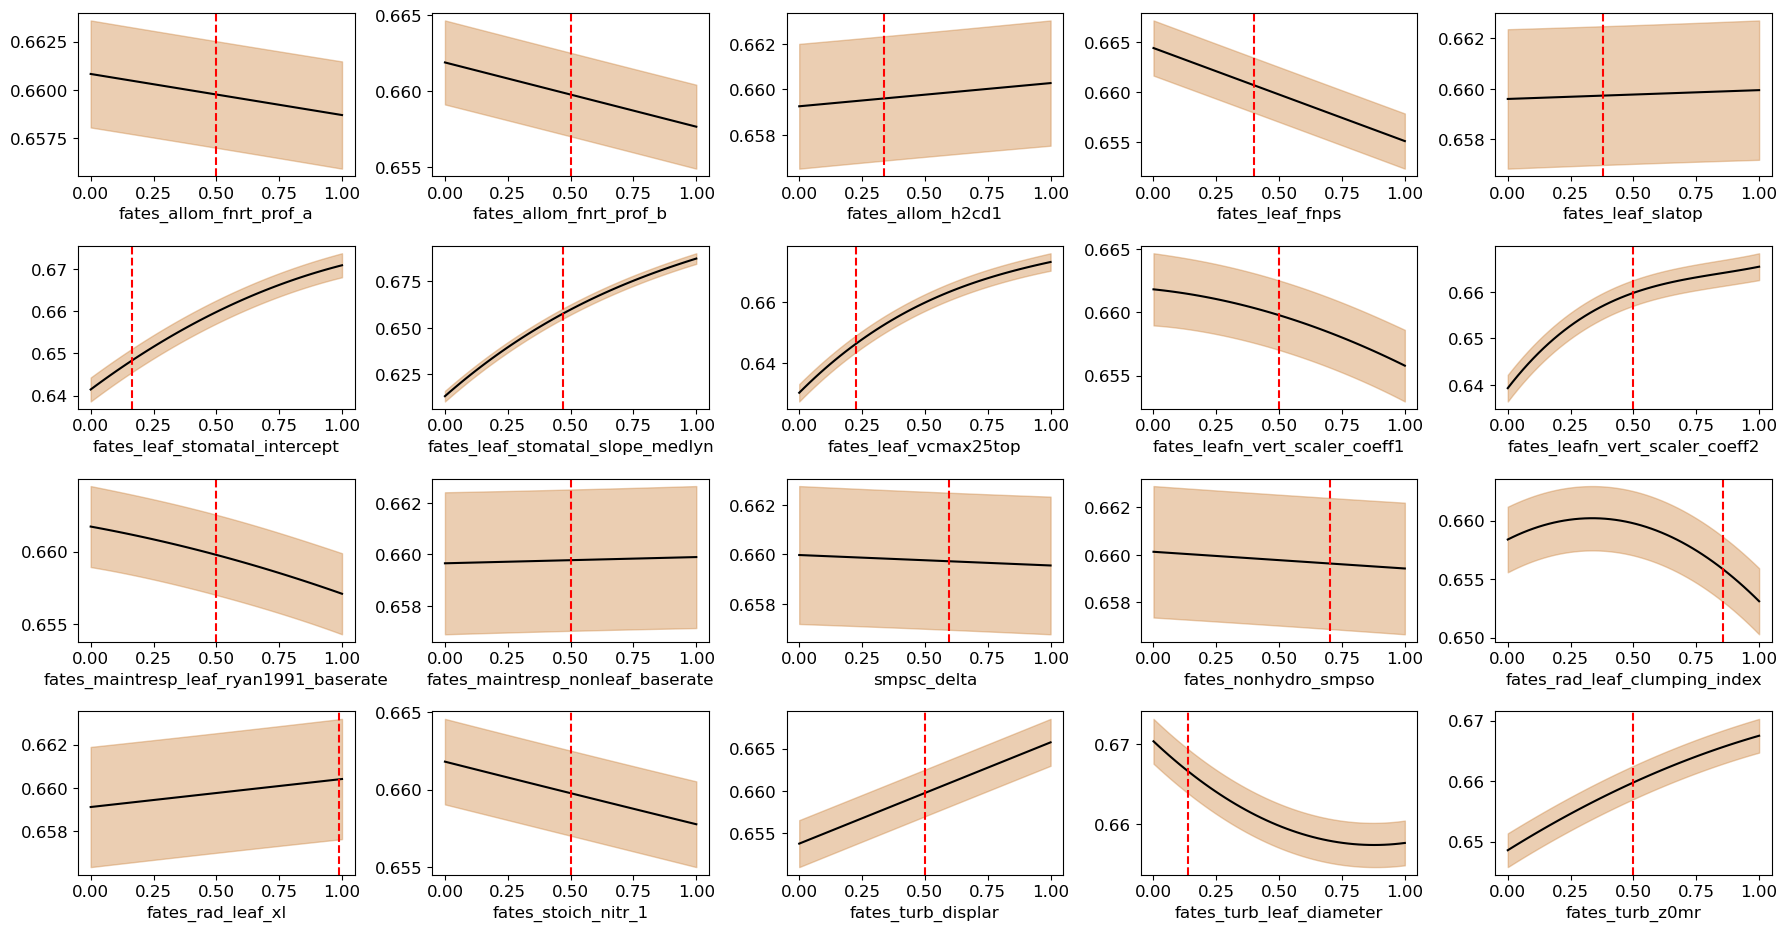

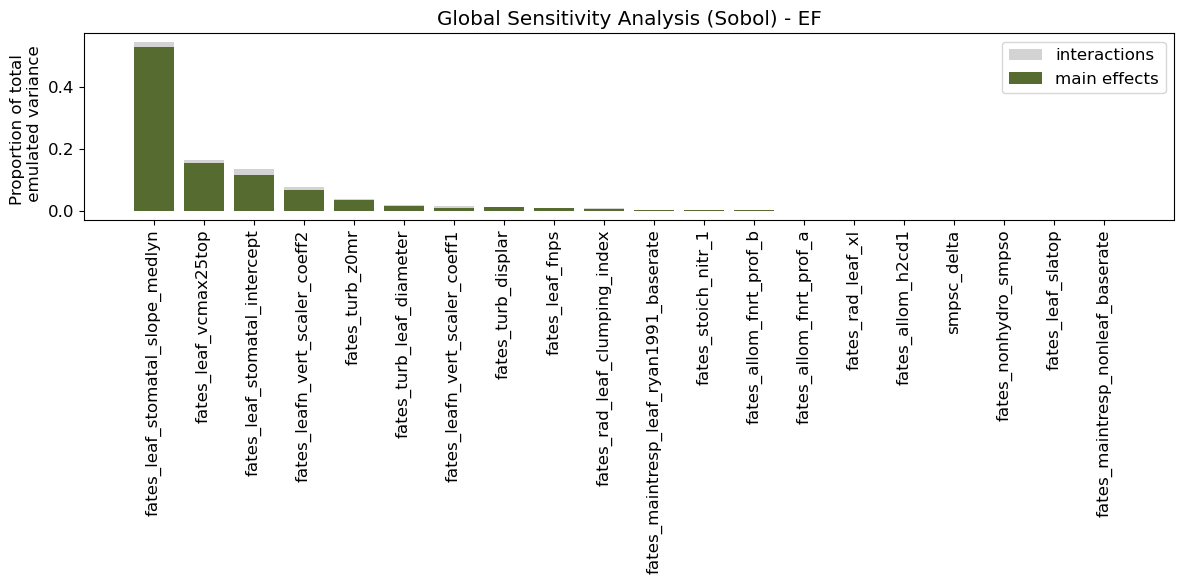

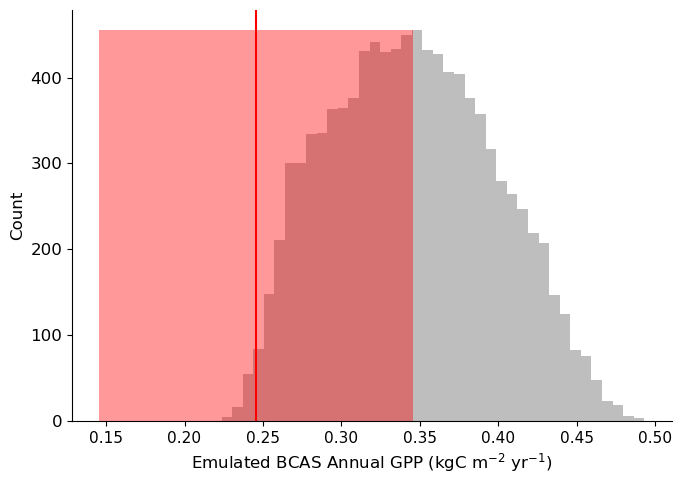

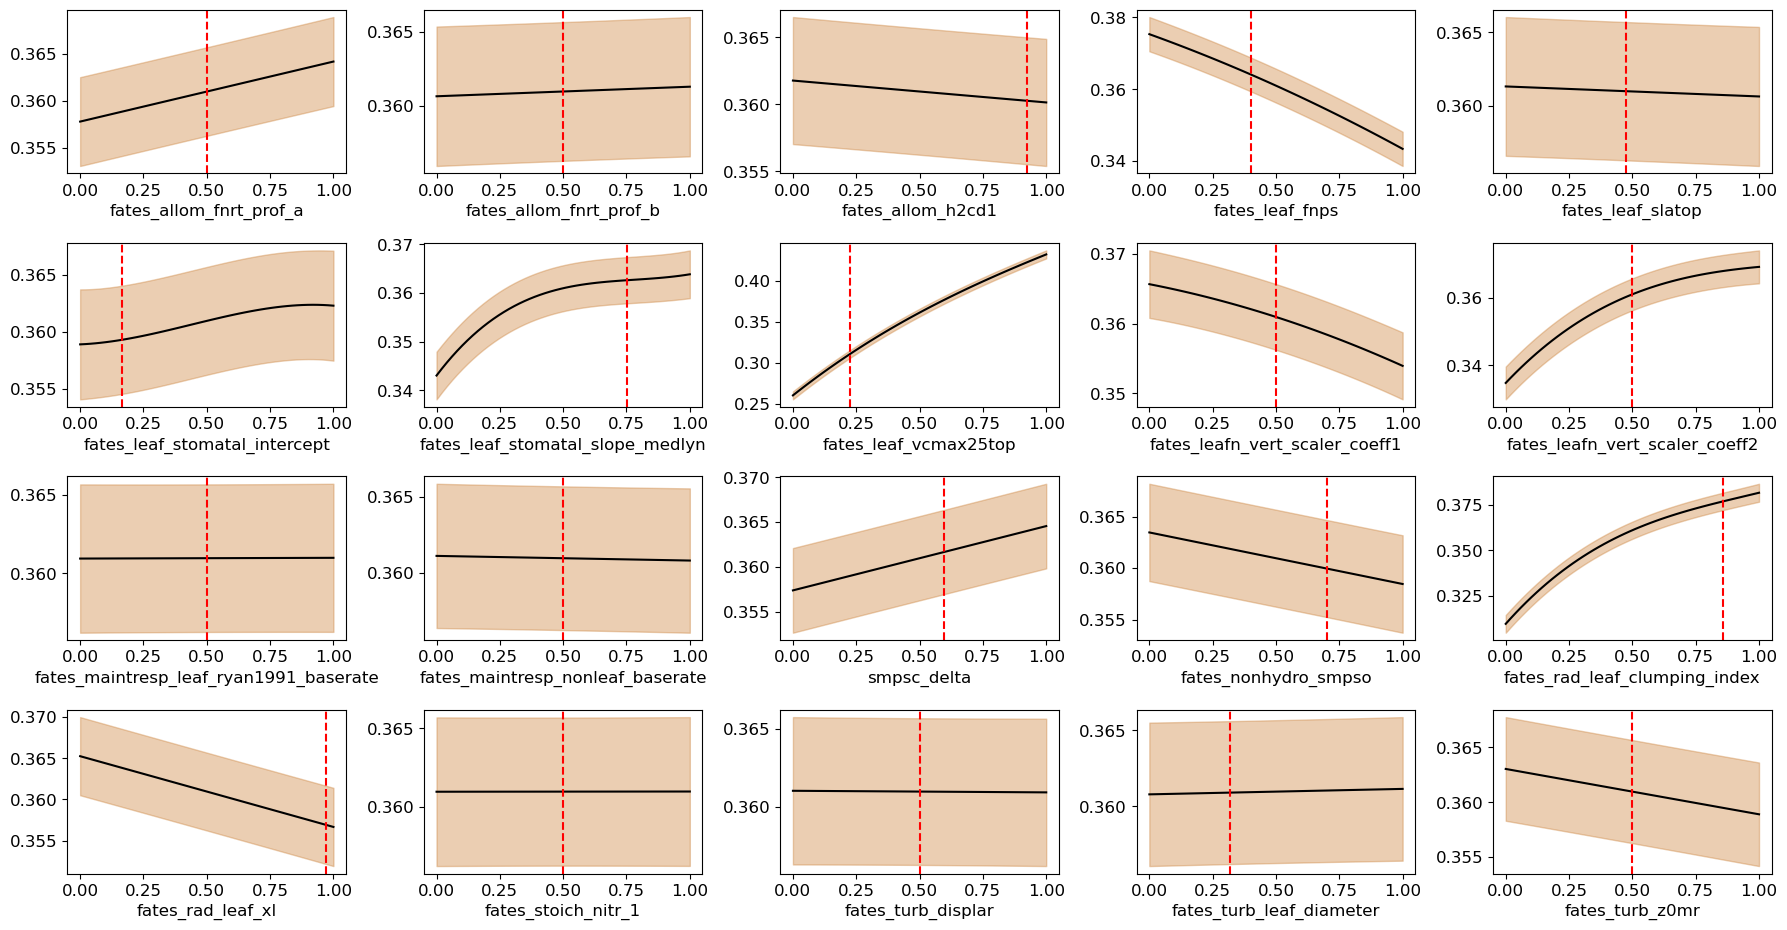

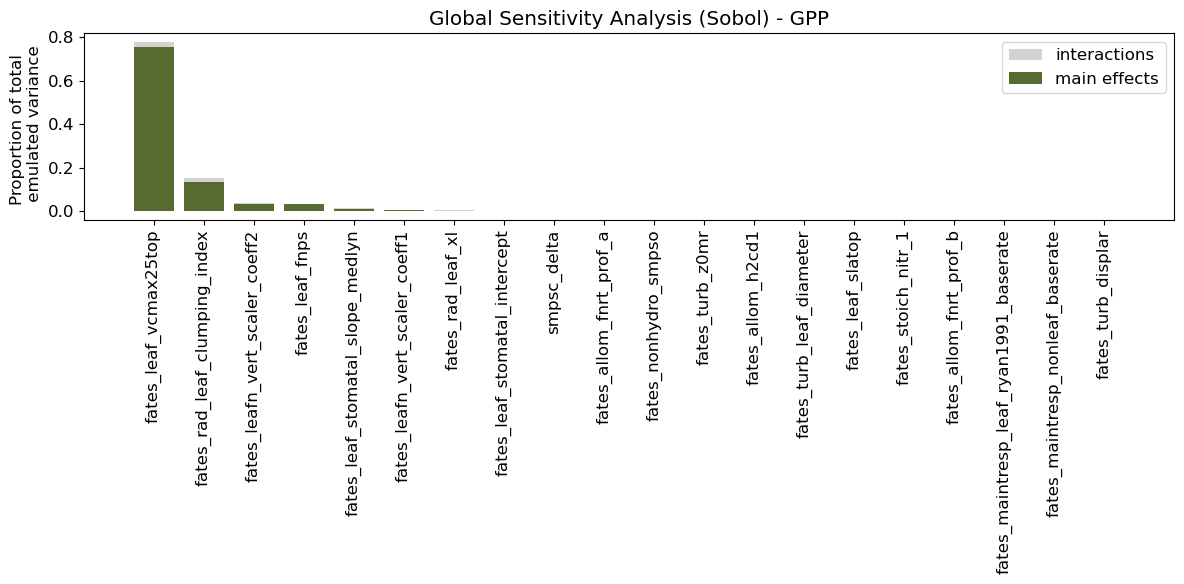

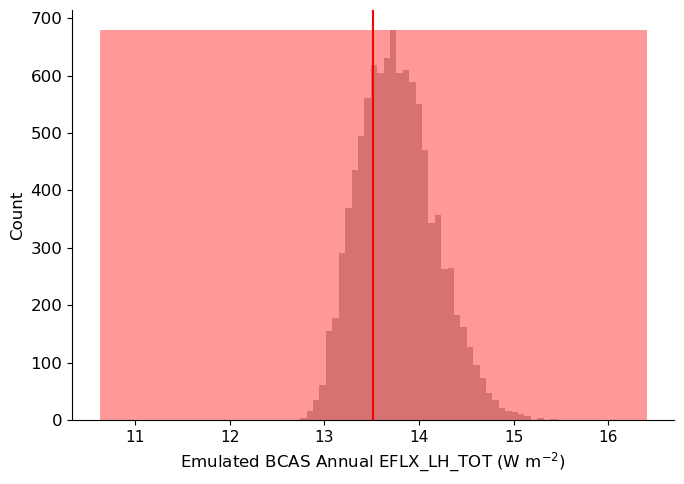

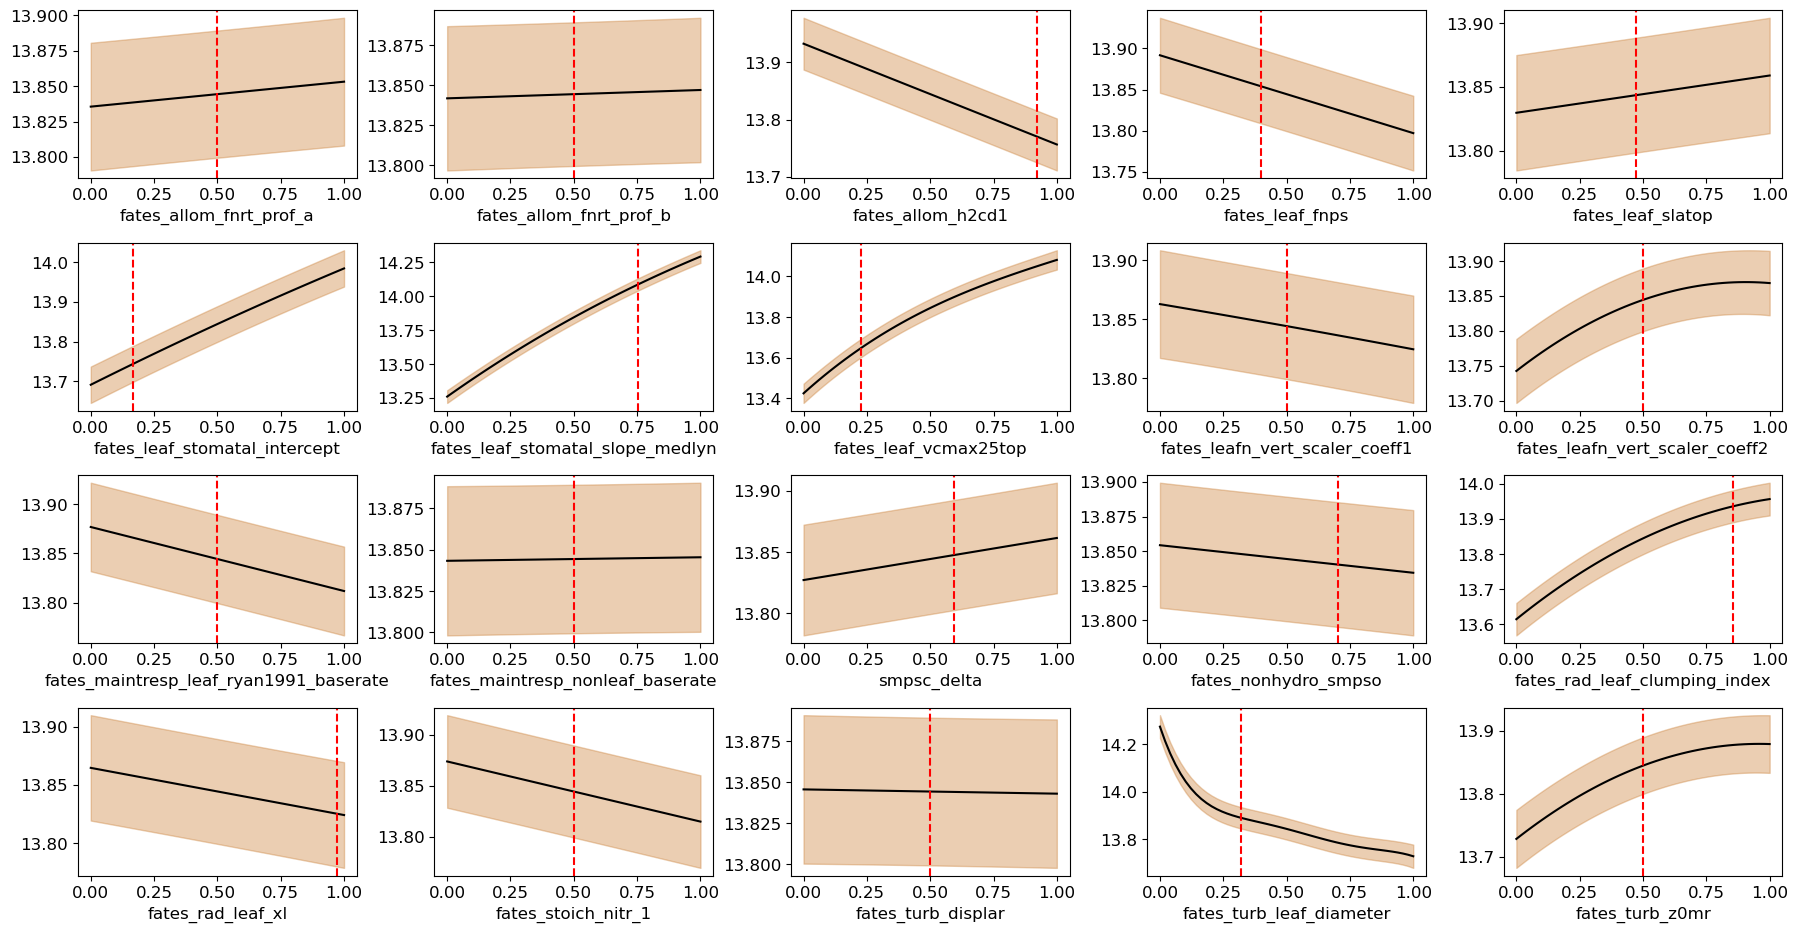

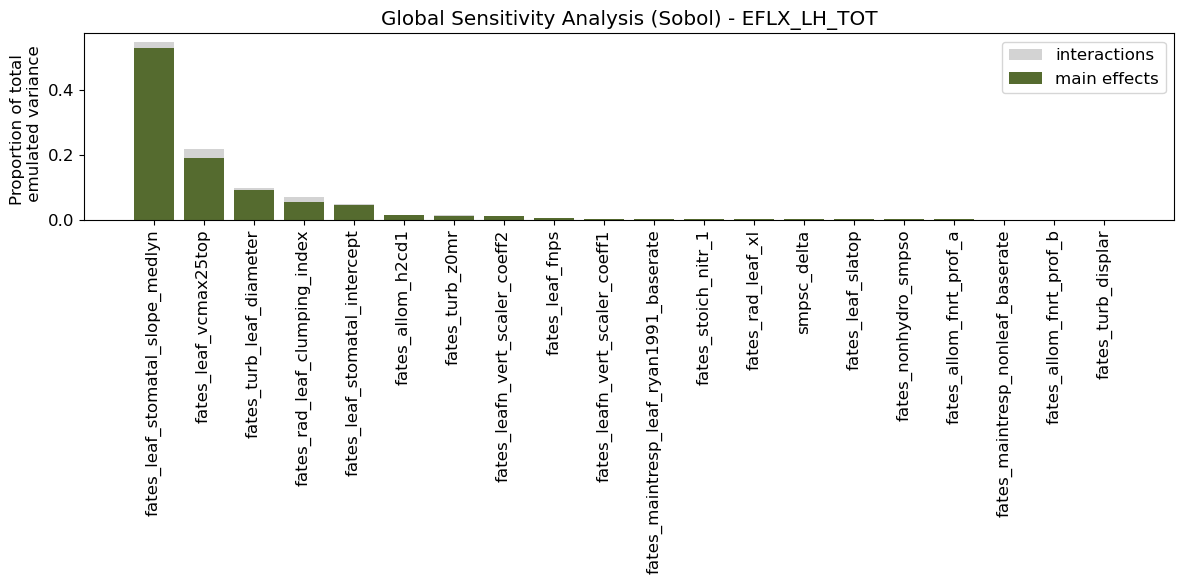

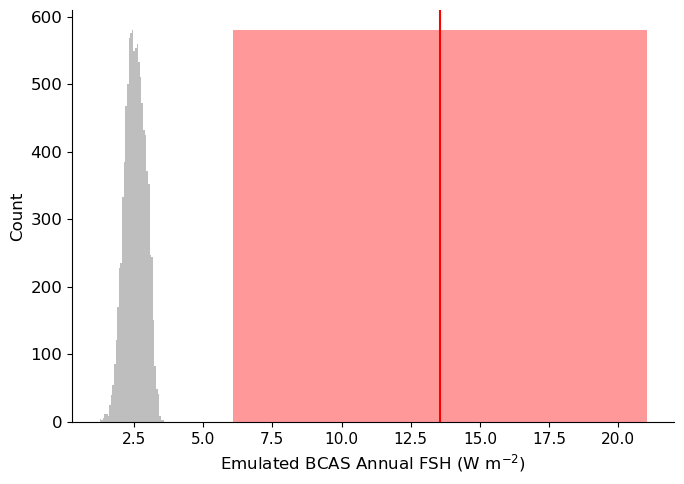

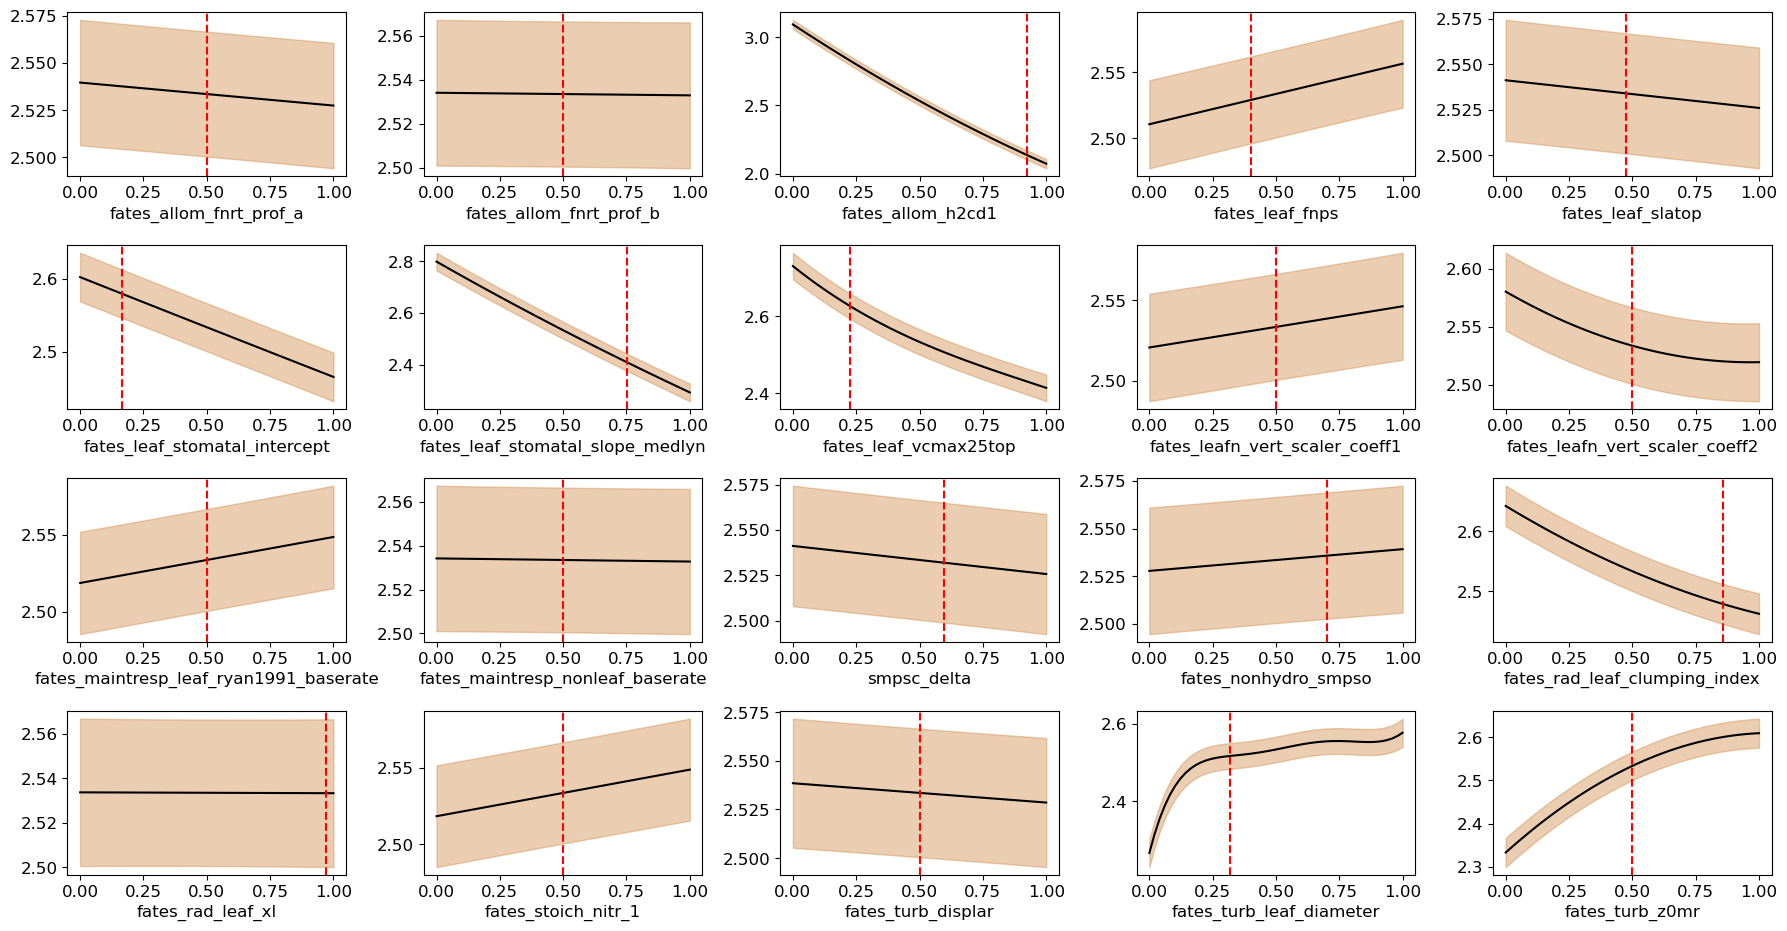

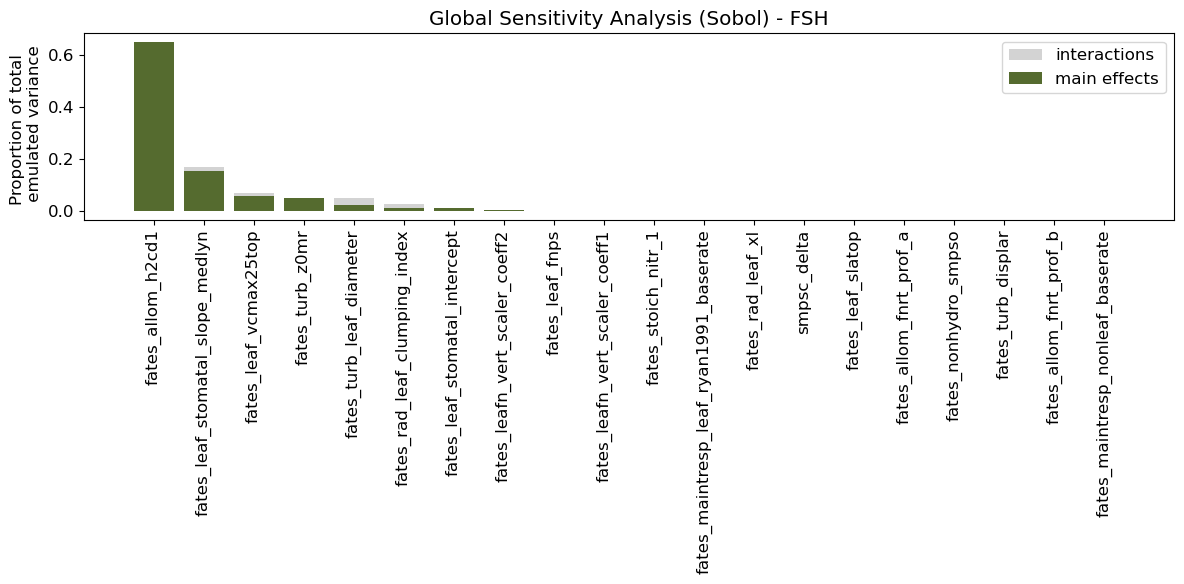

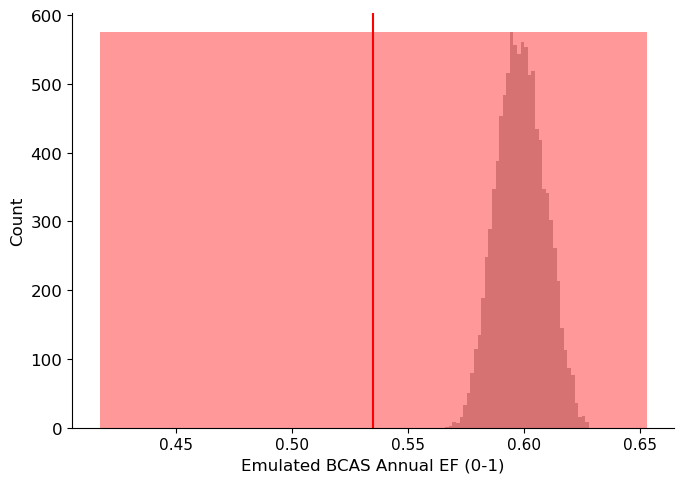

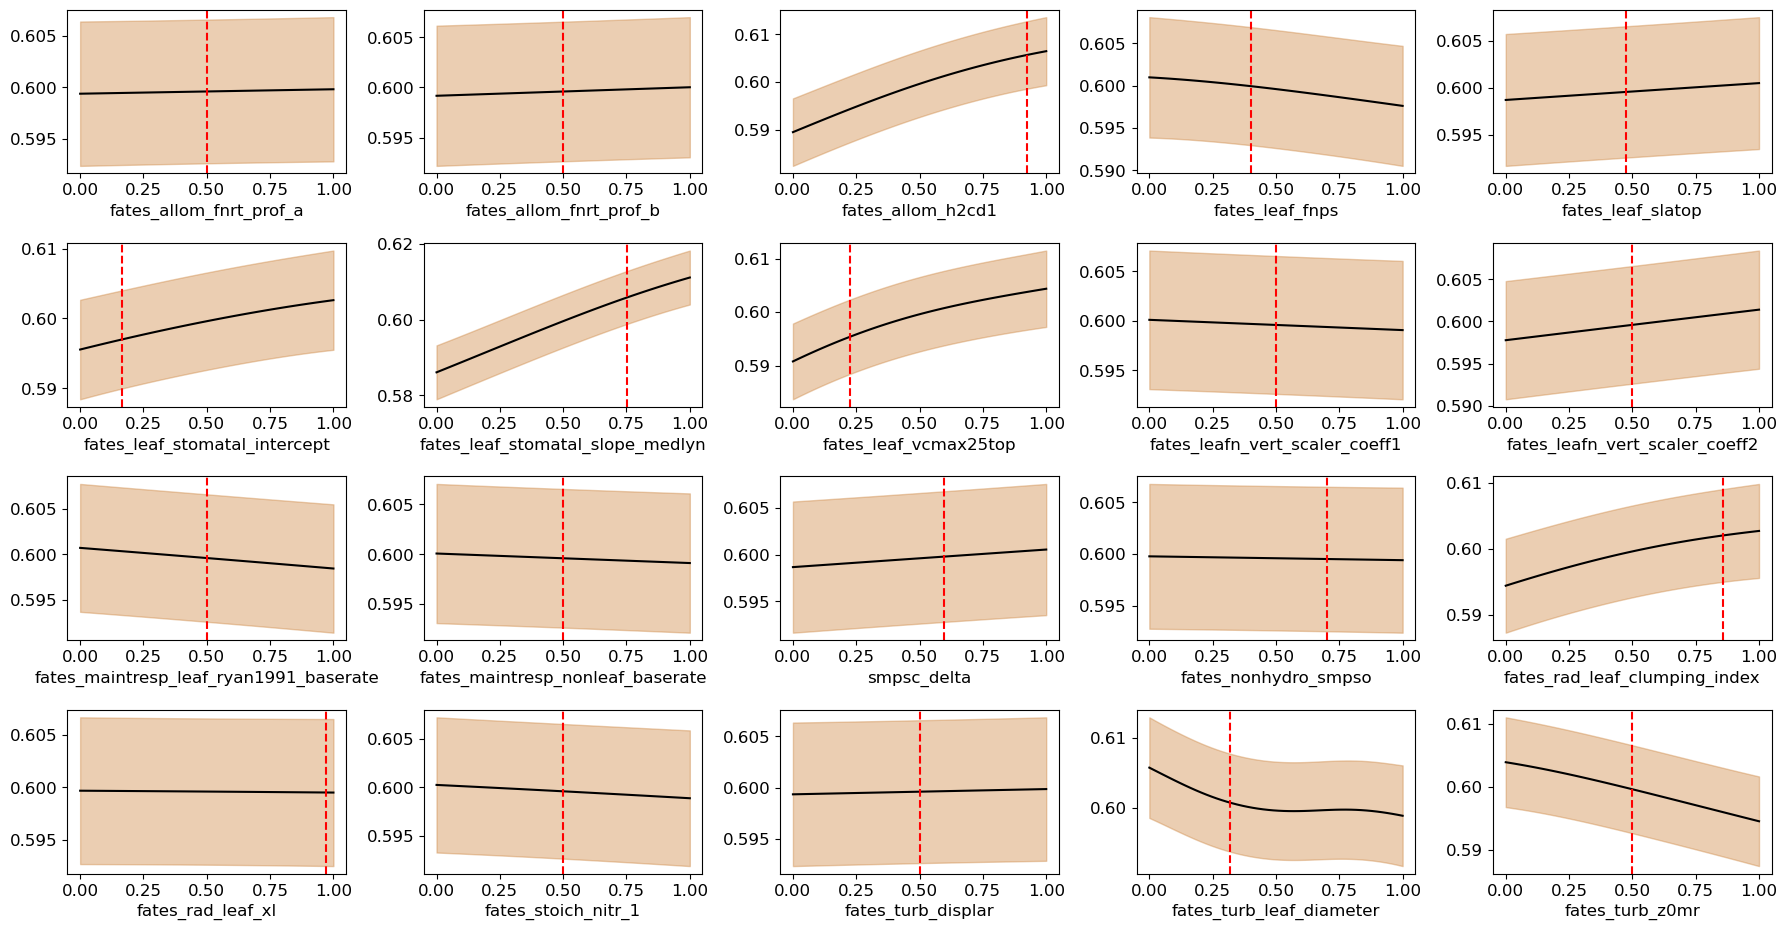

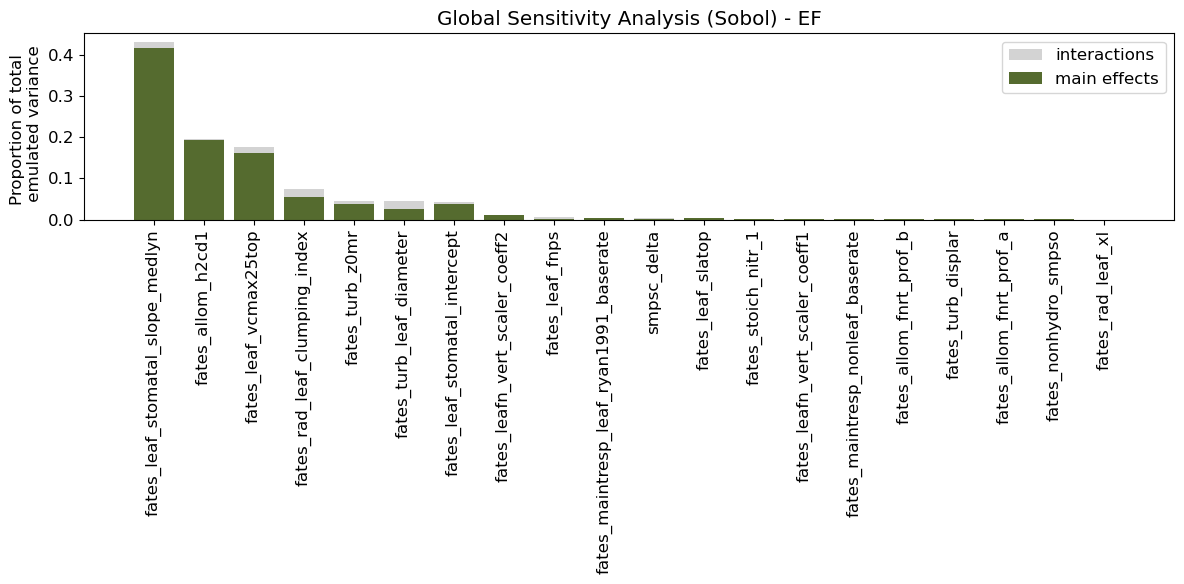

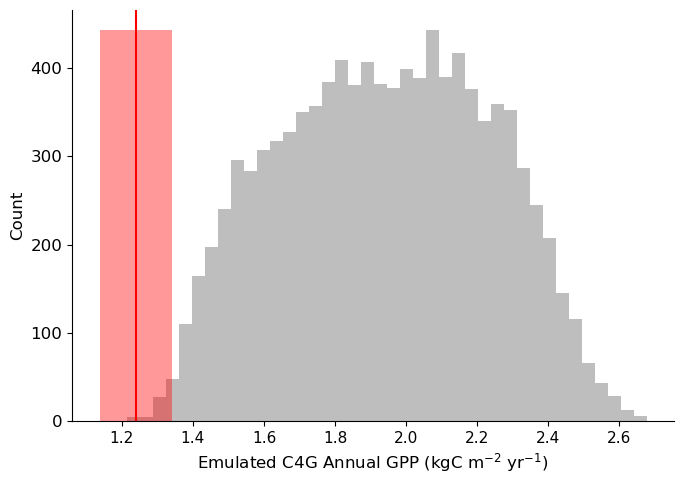

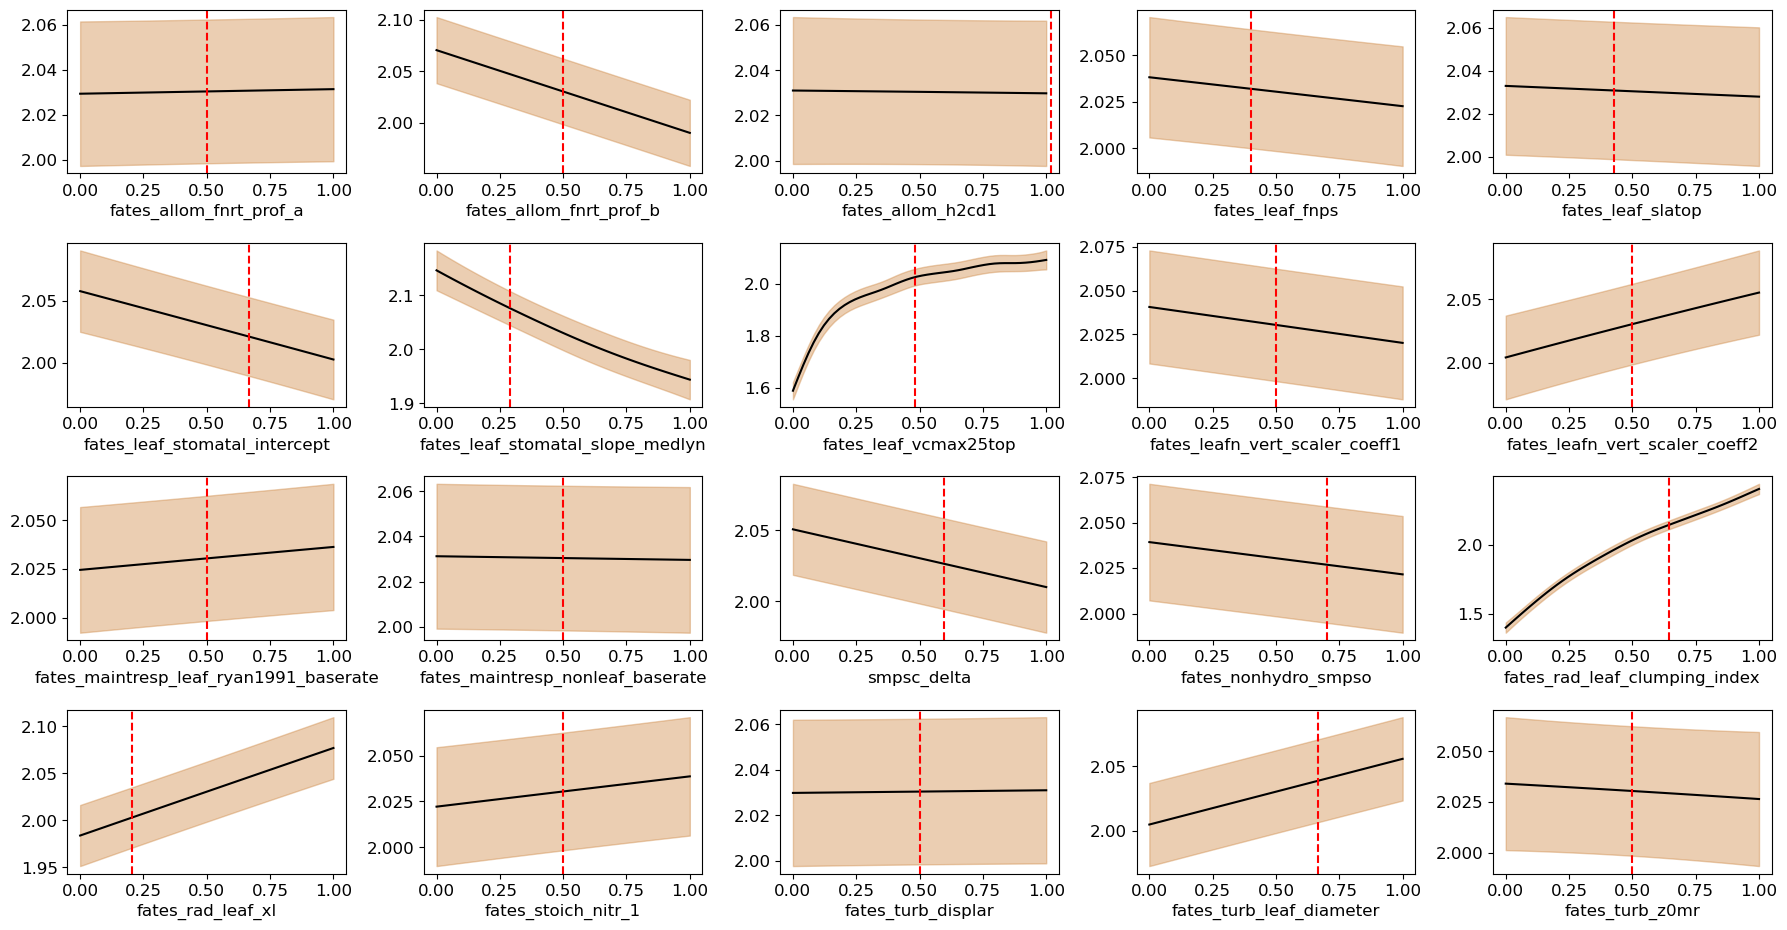

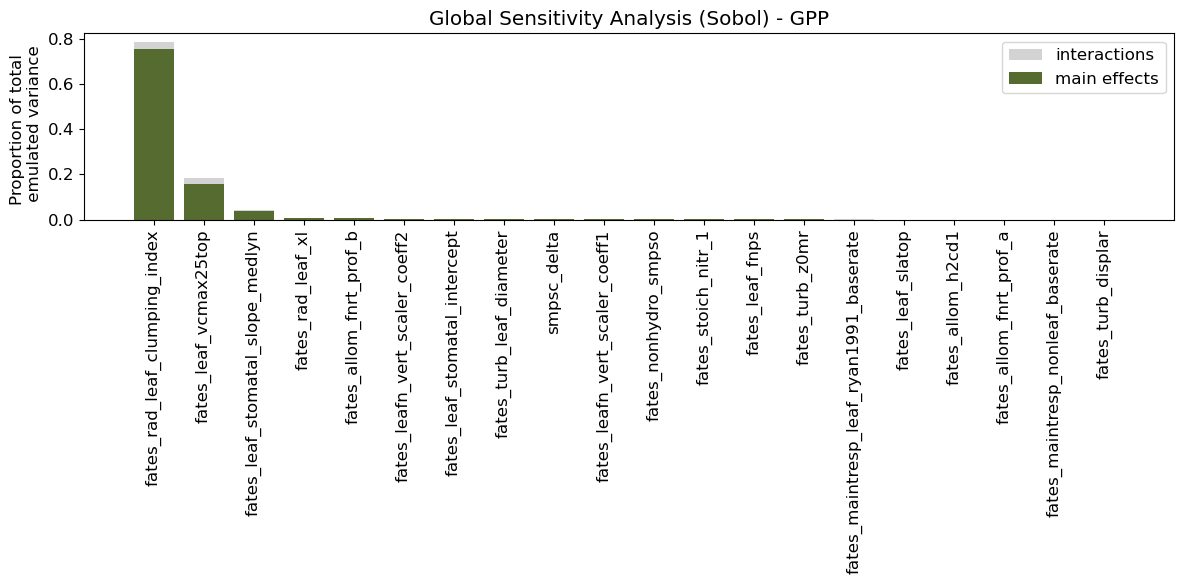

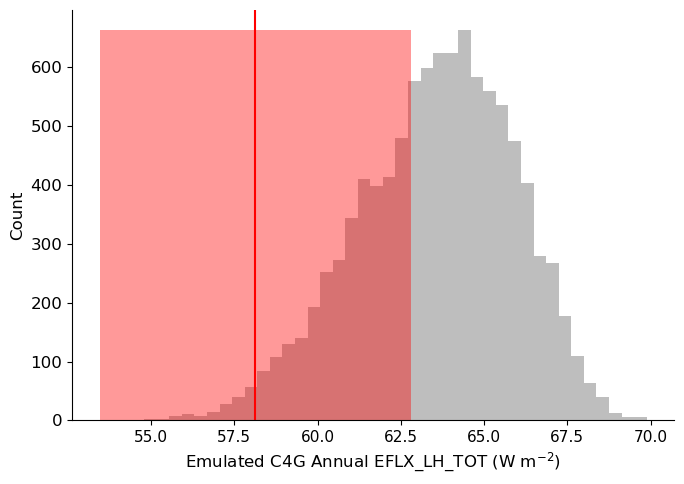

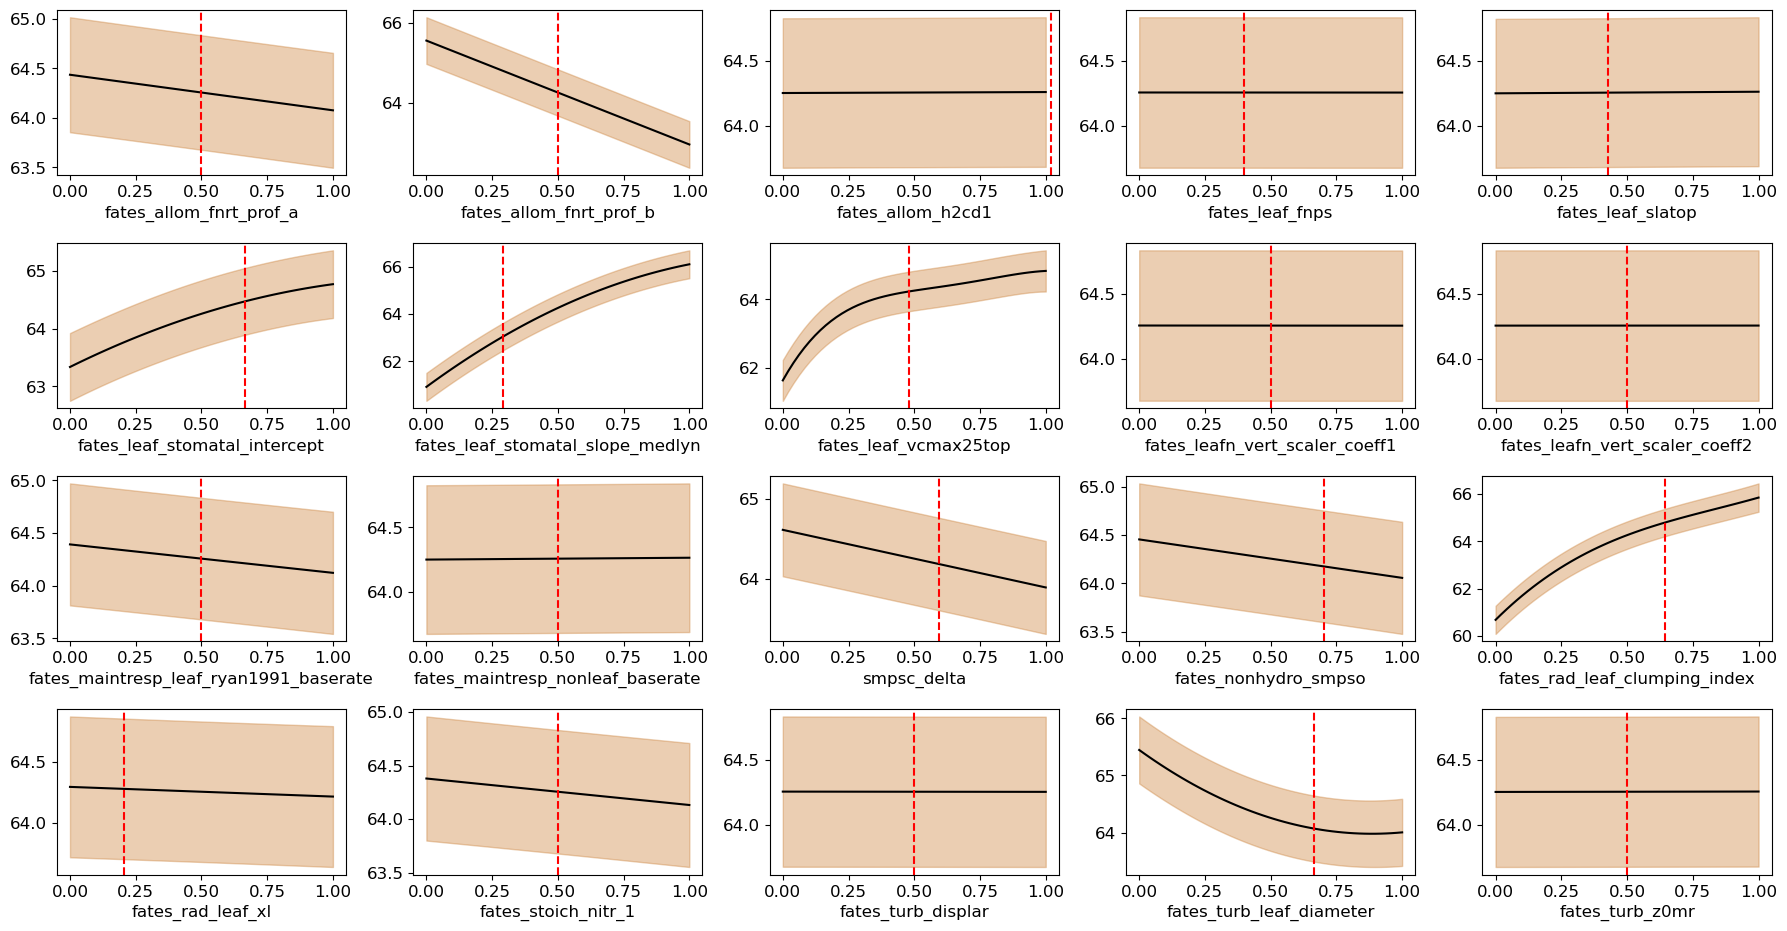

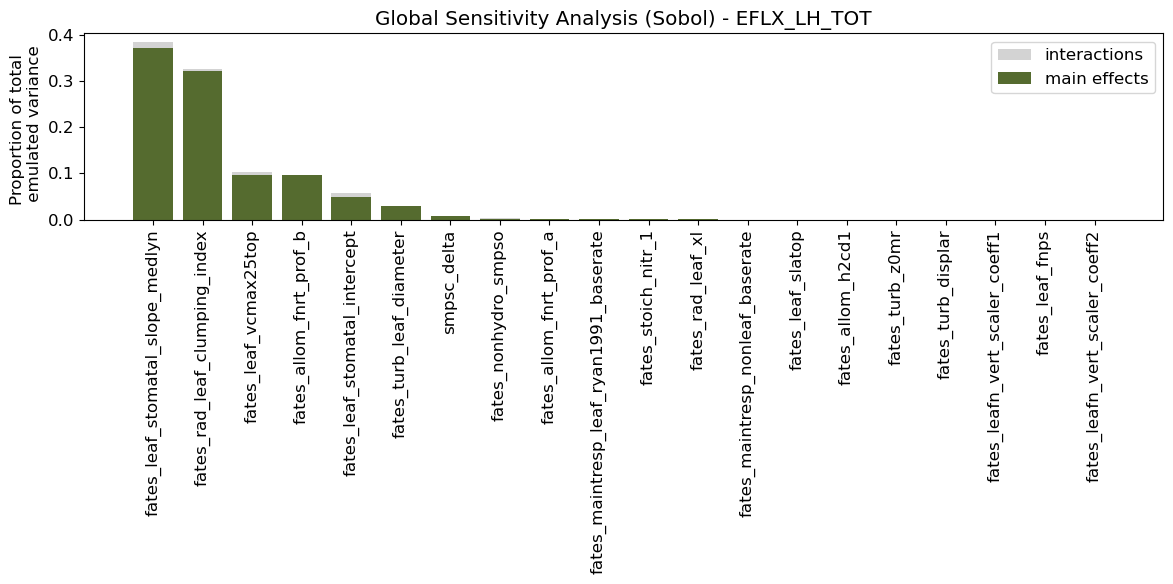

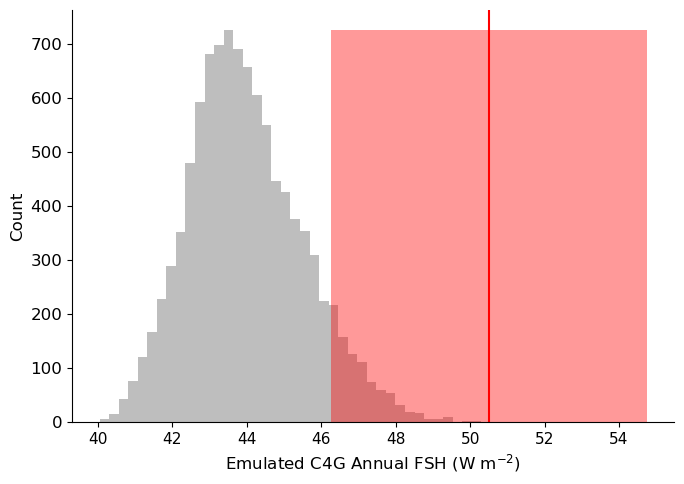

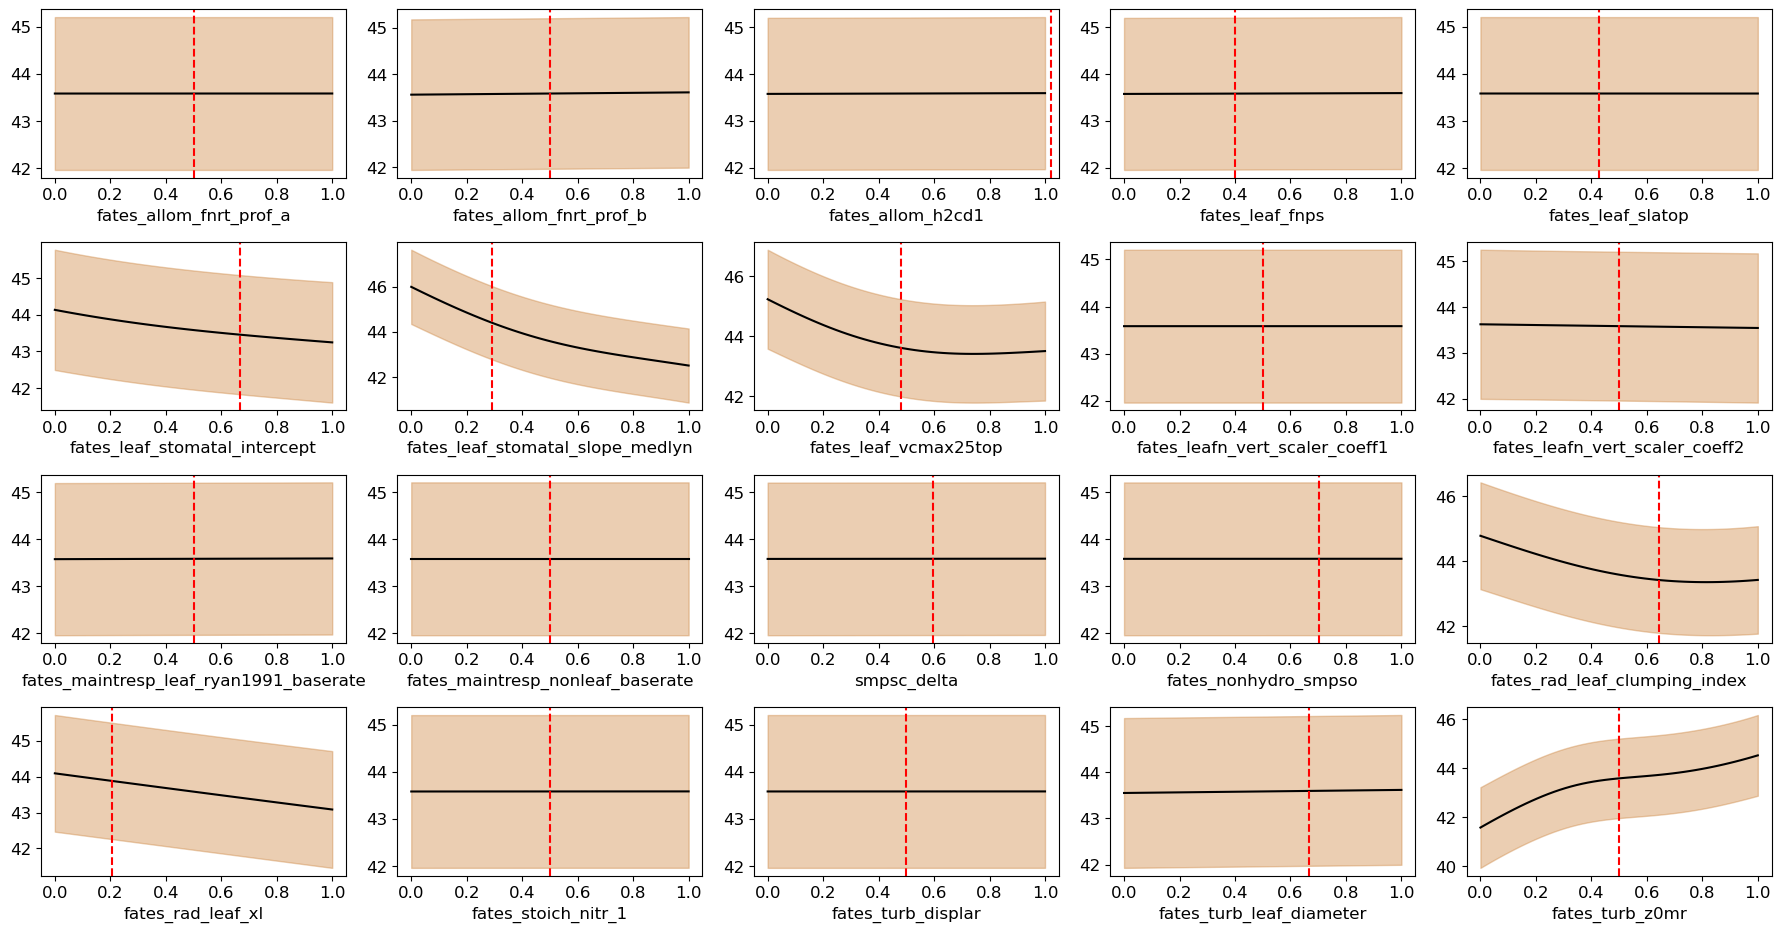

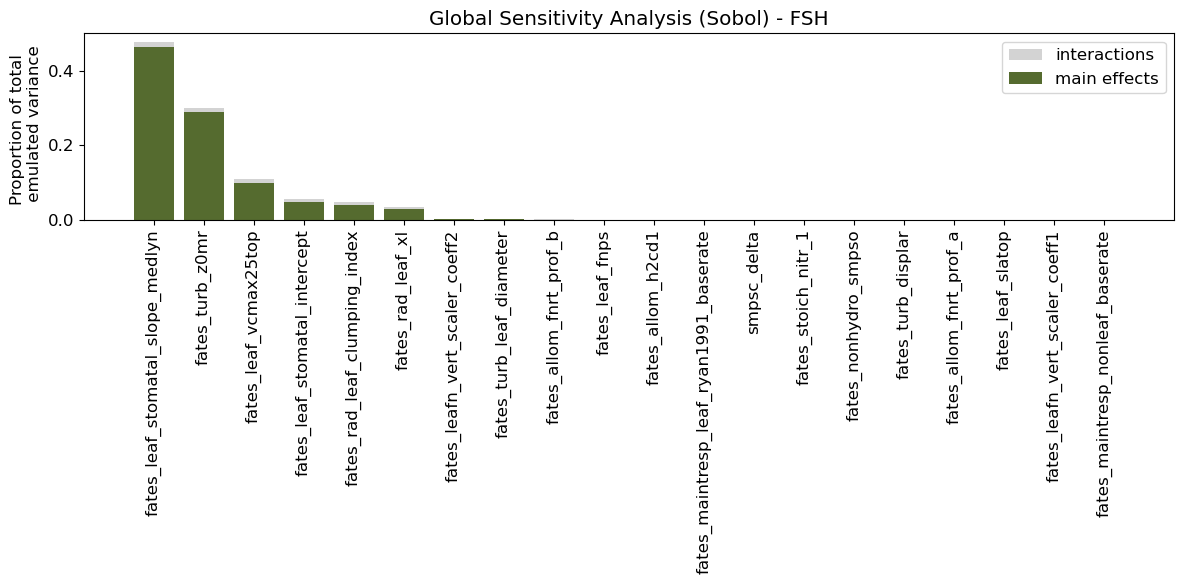

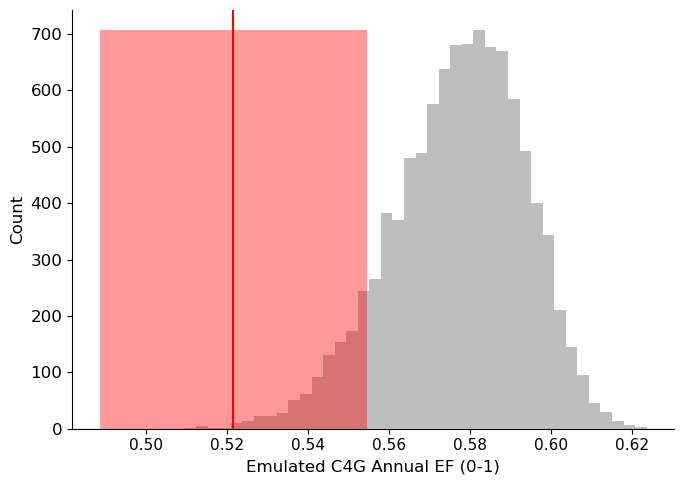

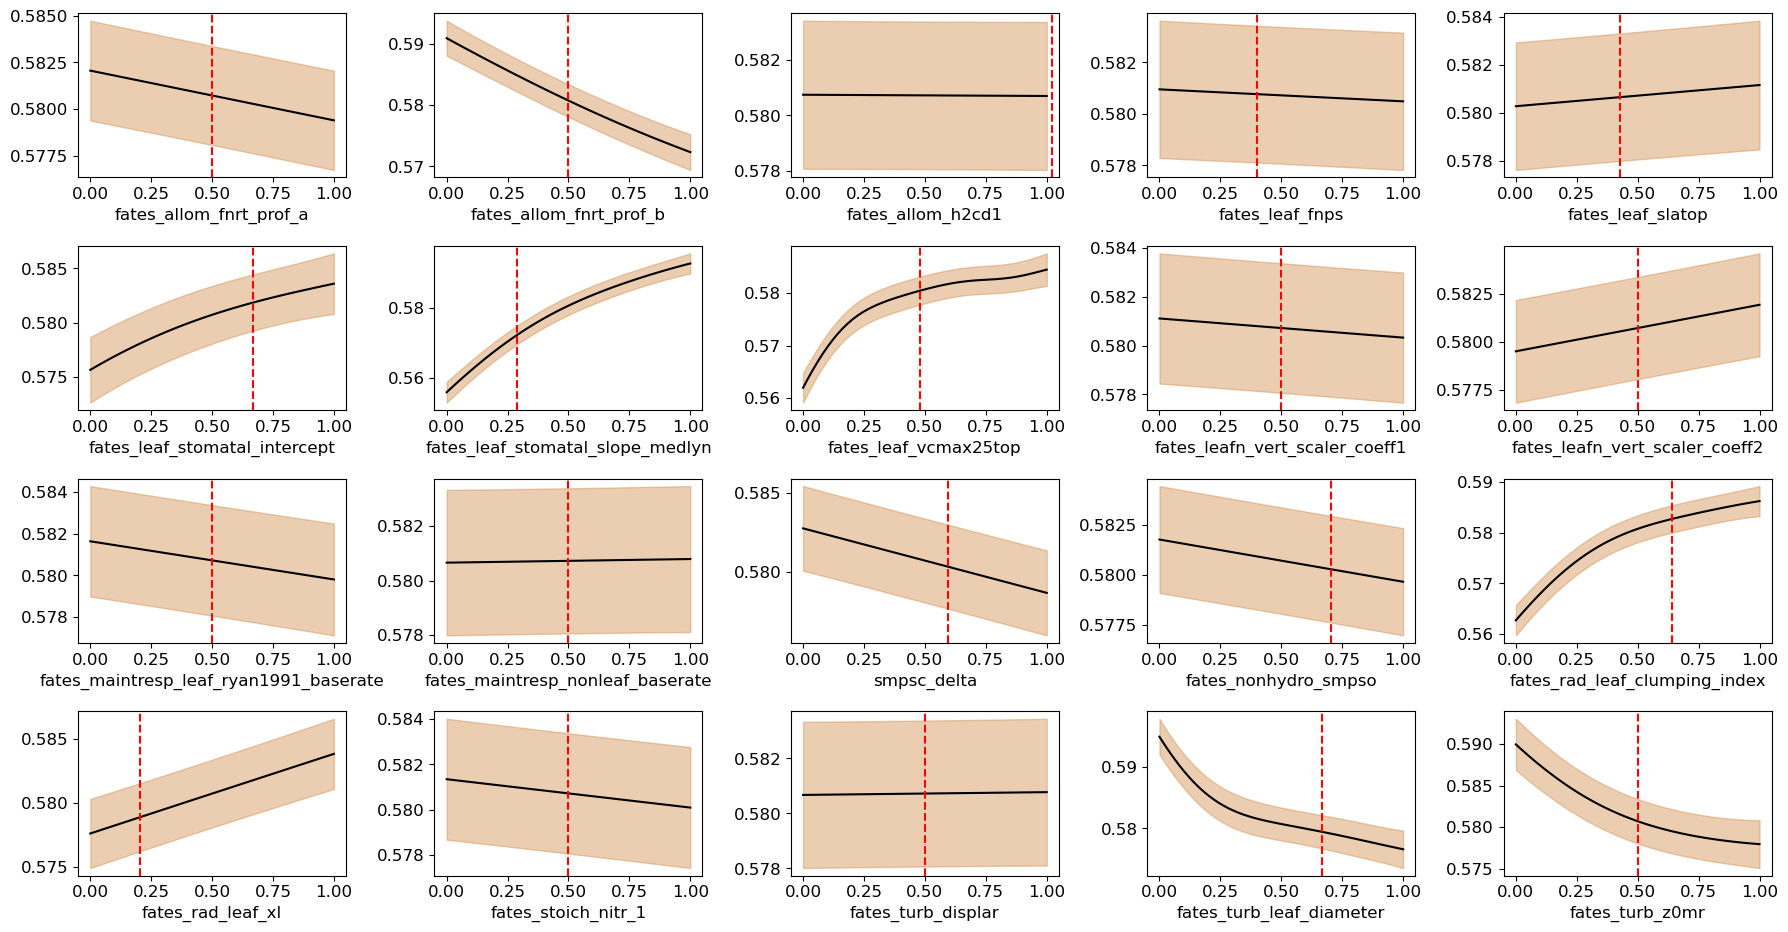

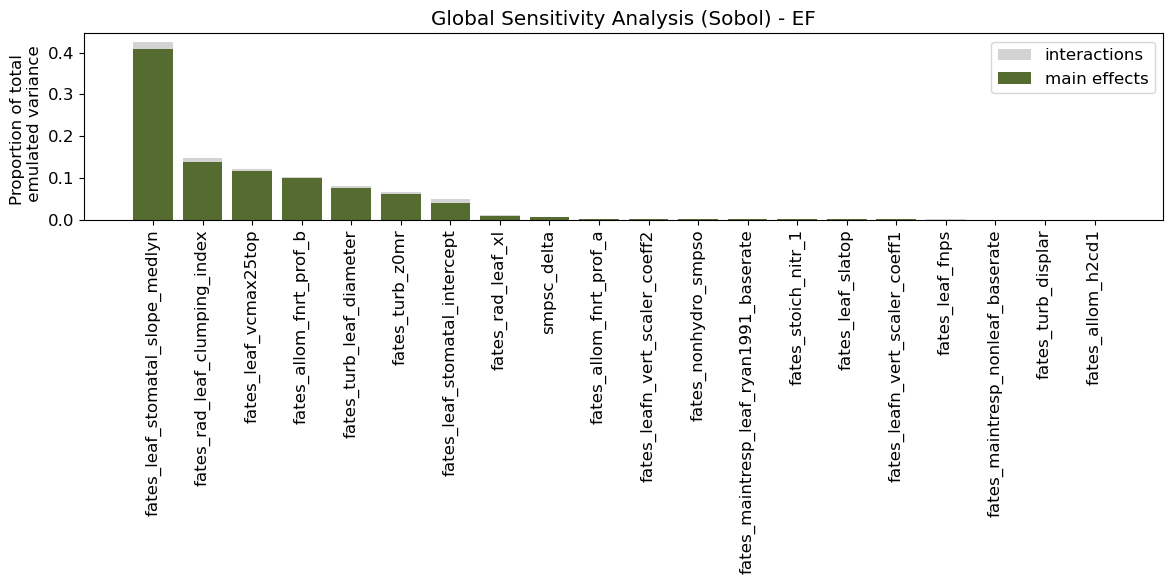

In [67]:
sens_dfs = []
sample_dfs = []
for pft in ens_dict[ensemble]['pfts']:
    
    pft_name = all_pfts[pft-1]
    pft_id = pft_ids[pft_name]
    
    # get observations for this pft
    default_pft = default_norm[default_norm.pft == pft]
    default_pft = default_pft.drop(columns = ['pft'])

    # get observations for this pft
    obs_pft = obs[obs.pft == pft_name]

    if pft != 4:
        obs_pft = obs_pft[obs_pft.land_frac > 0.99]

    if pft != 12:
        obs_pft = obs_pft[obs_pft.pct_lake < 30]

    for variable in calibration_vars:
        
        # get weighted mean and sd for the observations
        obs_mean, obs_sd = em.get_obs_mean_and_sd(obs_pft, obs_config[variable]['var'])

        # load emulator
        model = TFEmulator(emulator_dir, pft=pft_id, variable=variable)

        # generate a random sample and emulate on it
        sample = get_random_params(len(param_names), n_sample)
        pred_sampled, pred_sampled_var = model(sample)

        sample_df = pd.DataFrame(sample)
        sample_df.columns = param_names
        sample_df['pred'] = pred_sampled.numpy().flatten()
        sample_df['pred_var'] = pred_sampled_var.numpy().flatten()
        sample_df['variable'] = variable
        sample_df['pft'] = pft_id
        sample_dfs.append(sample_df)

        # plot histogram of emulated values
        em.plot_emulated_sample(pred_sampled.numpy().flatten(), obs_mean, obs_sd,
                                pft_id, variable, obs_config[variable]['global_units'])
        plt.savefig(os.path.join(fig_dir, 'emulator_figs', f"emulated_sample_{variable}_{pft_id}.png"))

        # sensitivity analysis
        dat = em.plot_oaat_sens(param_names, model, default_pft)
        plt.savefig(os.path.join(fig_dir, 'emulator_figs', f"oaat_sens_{variable}_{pft_id}.png"))

        sens_df = em.sensitivity_analysis(model, param_names)
        sens_df['pft'] = pft_id
        sens_df['variable'] = variable
        sens_dfs.append(sens_df)
        
        em.plot_global_sensitivity(sens_df, variable)
        plt.savefig(os.path.join(fig_dir, 'emulator_figs', f"sobol_sens_{variable}_{pft_id}.png"))
sample_df = pd.concat(sample_dfs)
sens_df = pd.concat(sens_dfs)

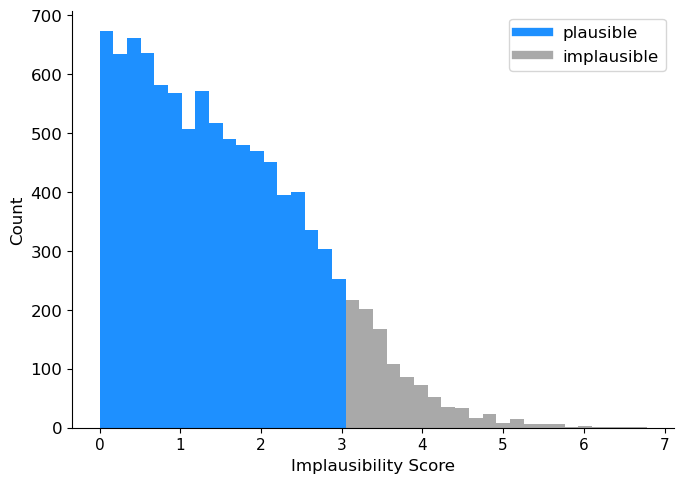

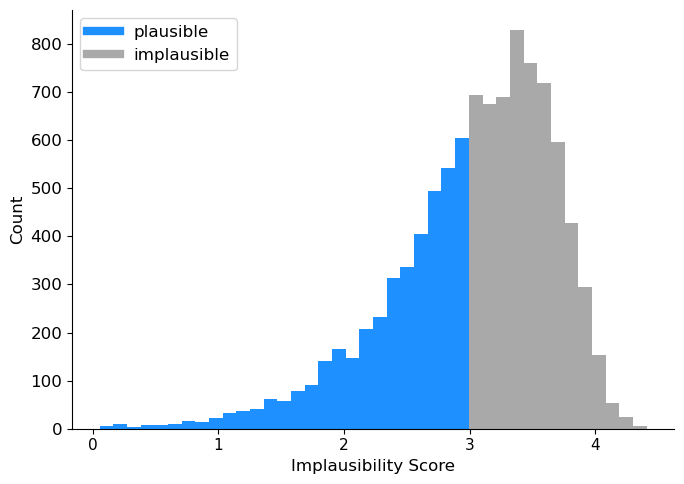

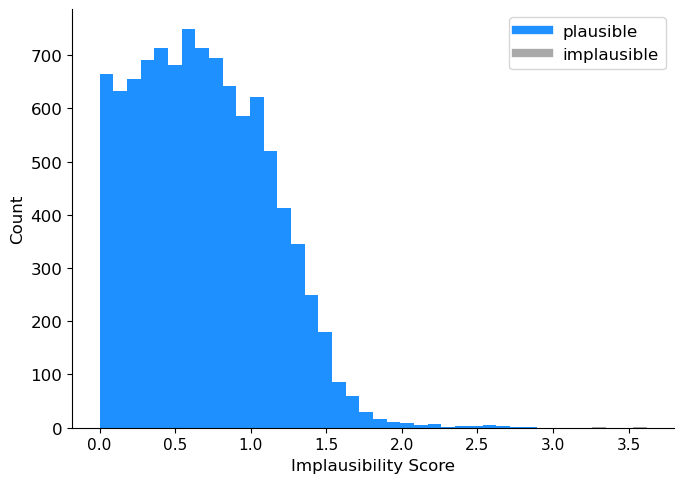

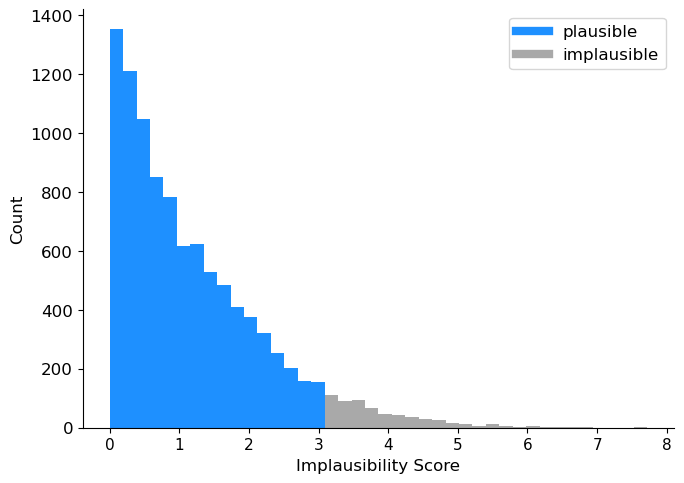

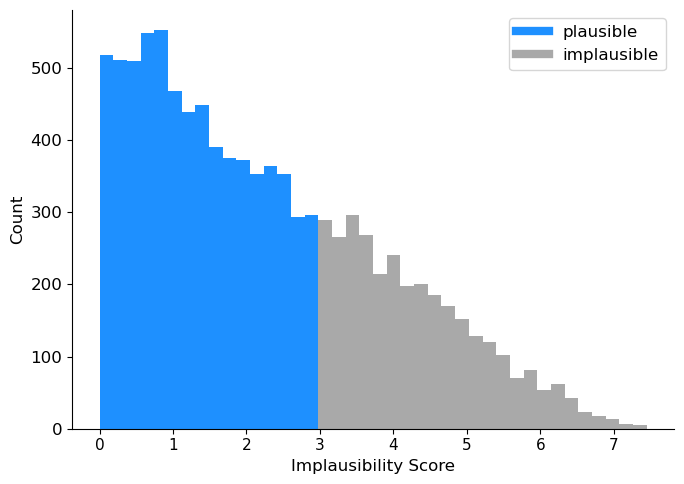

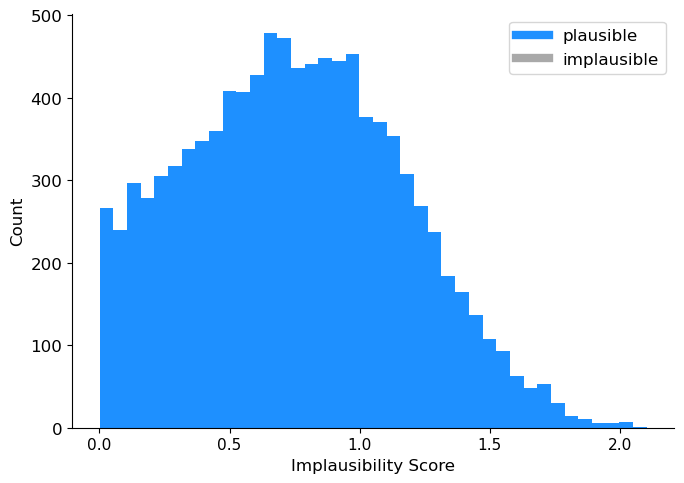

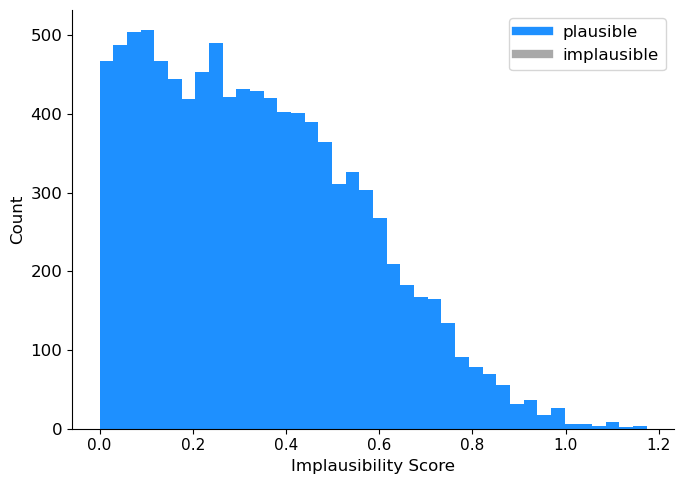

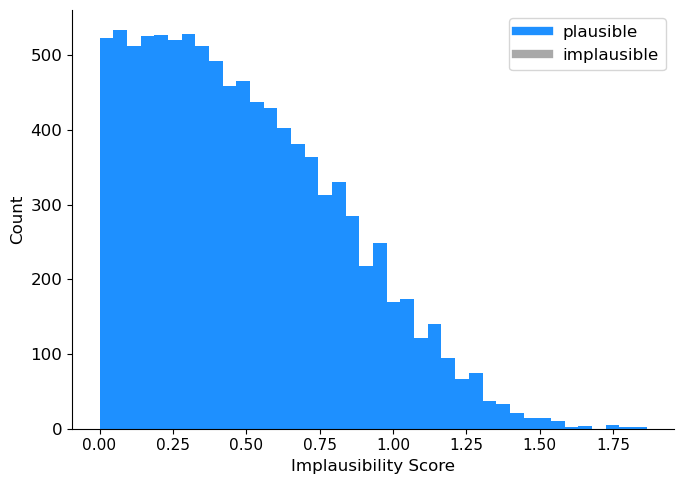

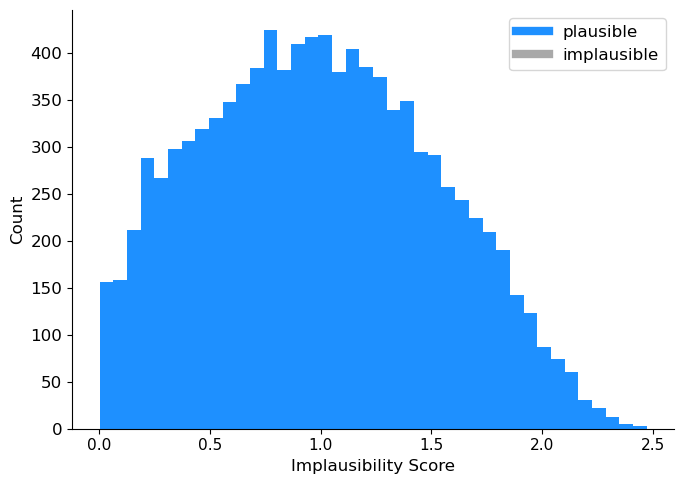

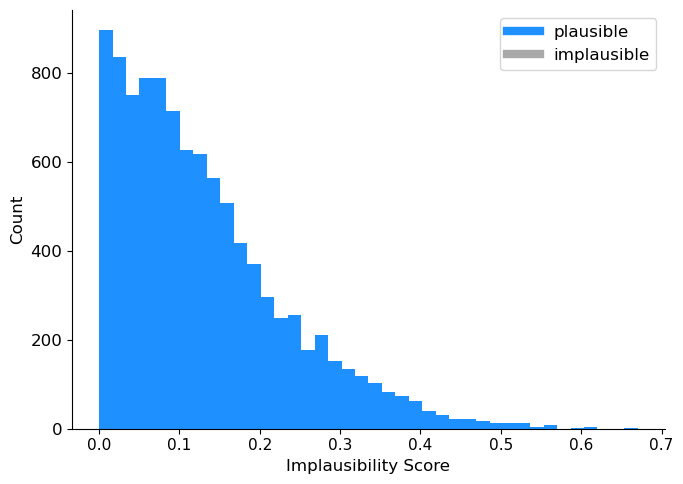

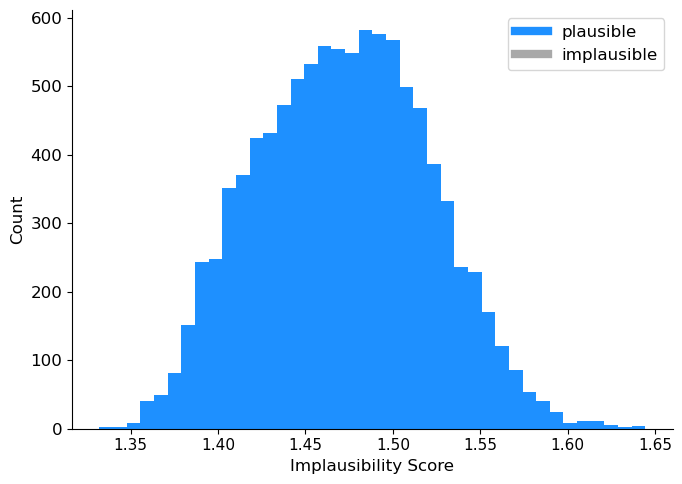

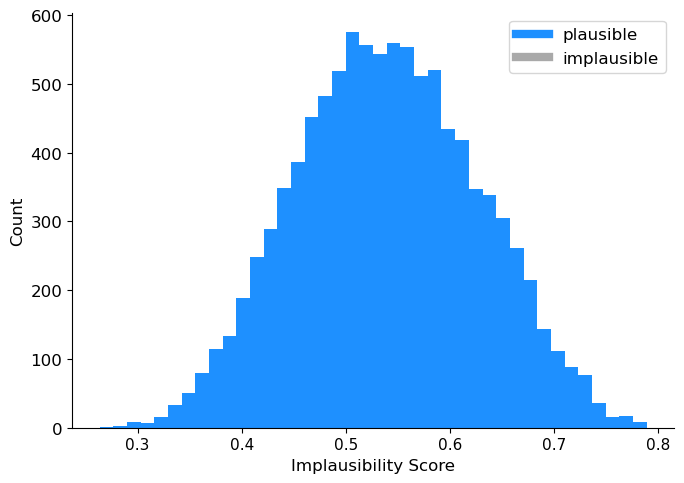

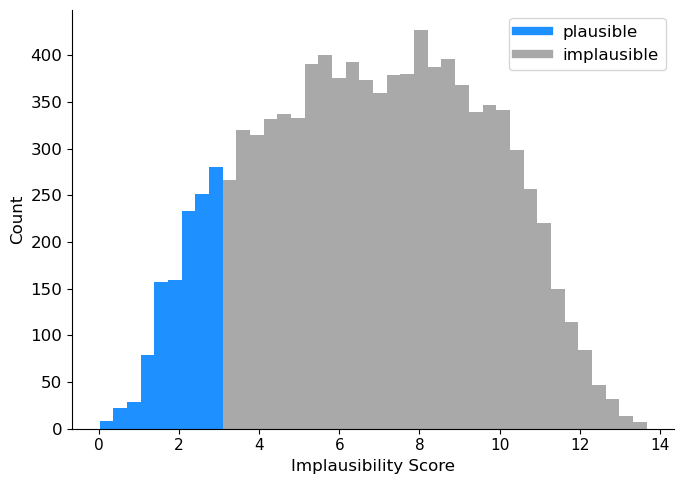

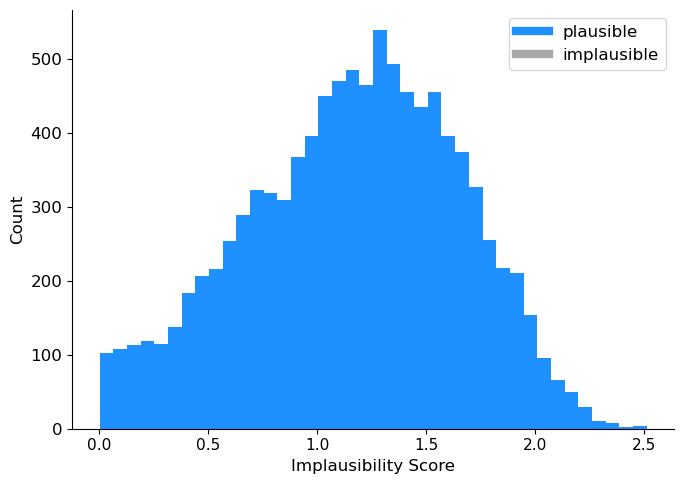

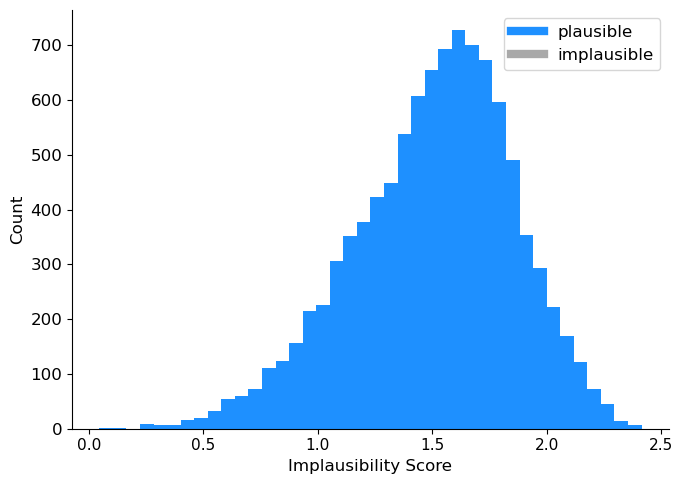

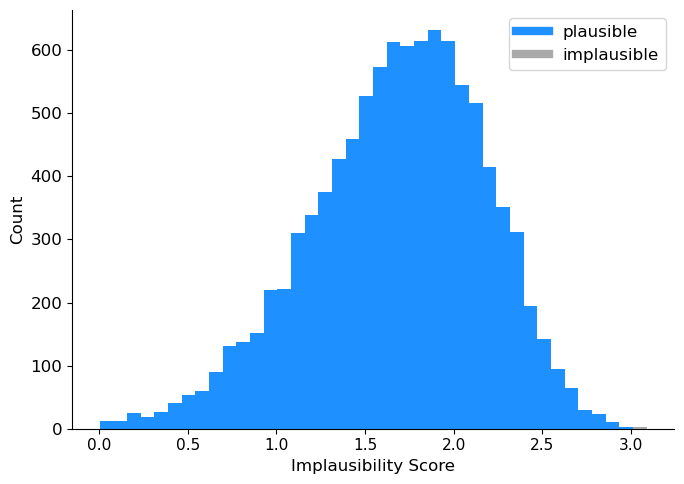

In [71]:
props = {}
sensitive_params = {}
for pft in ens_dict[ensemble]['pfts']:
    
    pft_name = all_pfts[pft-1]
    pft_id = pft_ids[pft_name]

    
    props[pft_id] = {}
    sensitive_params[pft_id] = {}
    
    obs_pft = obs[obs.pft == pft_name]
    if pft != 4:
        obs_pft = obs_pft[obs_pft.land_frac > 0.99]
    if pft != 12:
        obs_pft = obs_pft[obs_pft.pct_lake < 30]
    df = sample_df[sample_df.pft == pft_id]
    pft_sens = sens_df[sens_df.pft == pft_id]
    
    for variable in calibration_vars:
        
        # get weighted mean and sd for the observations
        obs_mean, obs_sd = em.get_obs_mean_and_sd(obs_pft, obs_config[variable]['var'])
        df_var = df[df.variable == variable]
        pft_sens_var = pft_sens[pft_sens.variable == variable]

        # implausibility score
        implaus = em.implausibility_metric(df_var.pred, obs_mean, df_var.pred_var, obs_sd**2)

        em.plot_implausibility_histogram(implaus)

        props[pft_id][variable] = em.get_proportion_implausible(implaus, 1)
        sensitive_params[pft_id][variable] = np.unique(pft_sens_var[pft_sens_var.ST >= 0.01]['parameter'])
sample_props = pd.DataFrame.from_dict(props, orient='index')

In [72]:
sens_df.to_csv(os.path.join(emulator_dir, f'sensitivity_df_{ensemble}.csv'))
sample_props.to_csv(os.path.join(emulator_dir, f'sample_props_{ensemble}.csv'))

In [75]:
sens_df

,parameter,S1,S1_conf,ST,ST_conf,pft,variable
7,fates_leaf_vcmax25top,0.659489,0.030079,6.750158e-01,2.948443e-02,BEET,GPP
9,fates_leafn_vert_scaler_coeff2,0.103542,0.015122,1.207363e-01,7.901856e-03,BEET,GPP
4,fates_leaf_slatop,0.058641,0.013758,8.140651e-02,8.119702e-03,BEET,GPP
6,fates_leaf_stomatal_slope_medlyn,0.053339,0.011233,6.246835e-02,3.921826e-03,BEET,GPP
10,fates_maintresp_leaf_ryan1991_baserate,0.014292,0.007640,2.660863e-02,2.771884e-03,BEET,GPP
...,...,...,...,...,...,...,...
8,fates_leafn_vert_scaler_coeff1,0.000307,0.000597,1.925966e-04,9.414749e-06,C4G,EF
3,fates_leaf_fnps,0.000060,0.000353,6.768945e-05,2.815048e-06,C4G,EF
11,fates_maintresp_nonleaf_baserate,0.000017,0.000108,5.478130e-06,2.626829e-07,C4G,EF
17,fates_turb_displar,0.000009,0.000072,3.207403e-06,1.404872e-07,C4G,EF
